In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "."   # your main output folder

def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards.txt file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")

    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)

    return np.array(step_rewards)     # shape: (episodes, 500)


def load_all_agents(base_dir):
    """Load all agents (folders) and return dict: {agent_name: step_rewards_array}."""
    agents = {}

    for agent in os.listdir(base_dir):
        agent_path = os.path.join(base_dir, agent)
        if not os.path.isdir(agent_path):
            continue

        file_path = os.path.join(agent_path, "step_rewards.txt")
        if not os.path.exists(file_path):
            print(f"Skipping {agent}: no step_rewards.txt")
            continue

        rewards = load_step_rewards(file_path)
        if rewards.size == 0:
            print(f"Skipping {agent}: no reward curves found")
            continue

        agents[agent] = rewards

    return agents


def compute_average_per_agent(step_rewards):
    """
    step_rewards: shape (episodes, 500)
    Returns: average cumulative reward curve, shape (500,)
    """
    cumulative = np.cumsum(step_rewards, axis=1)   # convert each episode to cumulative reward
    return cumulative.mean(axis=0)                 # average over episodes (100)




In [2]:
# -----------------------------------------------------
# MAIN
# -----------------------------------------------------

agents = load_all_agents(BASE_DIR)
print("Loaded agents:", list(agents.keys()))

# compute per-agent accumulated average curve
agent_avg_curves = {}
for agent, rewards in agents.items():
    agent_avg_curves[agent] = compute_average_per_agent(rewards)


Skipping .ipynb_checkpoints: no step_rewards.txt
Skipping 23Dec1740: no step_rewards.txt
Skipping 23Dec1818-worseThan1740: no step_rewards.txt
Skipping 23Dec1822: no step_rewards.txt
Skipping FSMultipleSwitchAgent1: no step_rewards.txt
Skipping FSRedAgentCombined_Figure: no step_rewards.txt
Skipping SleepSwitchFSRandom: no step_rewards.txt
Skipping pre Dec 20 results: no step_rewards.txt
Skipping preDec20model belief enabled results: no step_rewards.txt
Loaded agents: ['0-L25', '1', '1-L25', '100', '100-L25', '2-L25', '20', '20-L25', '3-L25', '300', '300-L25', '4-L25', '5', '5-L25', '50', '50-L25', '500-L25', 'FSRedAgentCombined', 'ImpacterSwitchFSRandom', 'ImpacterSwitchFSRandom-Freq5']


In [3]:
# -----------------------------------------------------
# Average *across* attack types
# -----------------------------------------------------

all_curves = np.vstack(list(agent_avg_curves.values()))      # shape (#agents, 500)
mean_curve = all_curves.mean(axis=0)                          # final curve


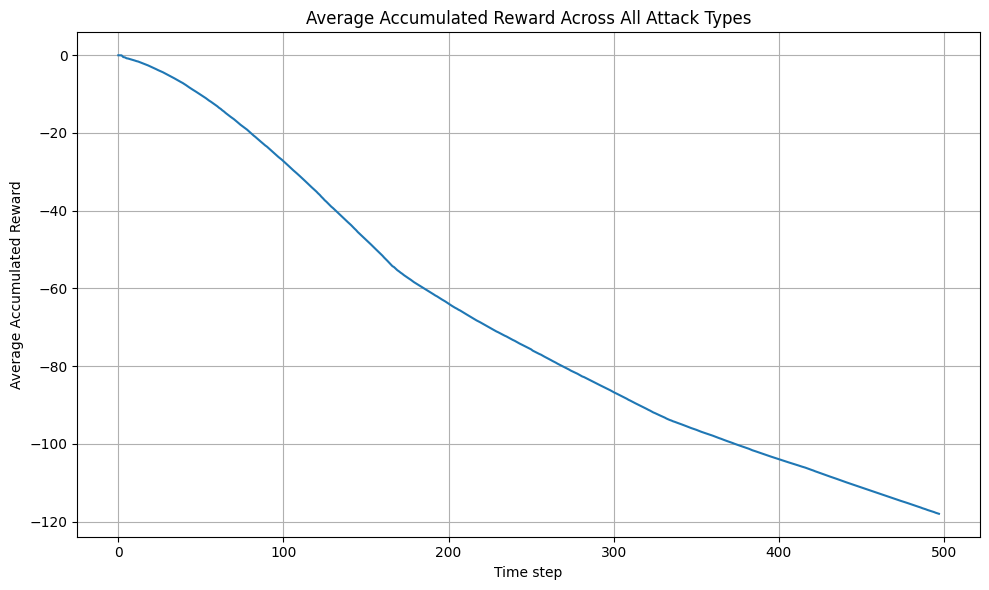

In [4]:
# -----------------------------------------------------
# Plot
# -----------------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(mean_curve)
plt.xlabel("Time step")
plt.ylabel("Average Accumulated Reward")
plt.title("Average Accumulated Reward Across All Attack Types")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import os
import ast
import numpy as np
import matplotlib.pyplot as plt


# --------------------------
# Helper: Load step_rewards.txt
# --------------------------
def load_step_rewards(path):
    """Loads the step_rewards.txt file and extracts per-episode reward curves."""
    curves = []
    with open(path, "r") as f:
        for line in f:
            if "step_rewards:" in line:
                # Extract list inside brackets
                list_str = line.split("step_rewards:")[1].strip()
                try:
                    rewards = ast.literal_eval(list_str)
                    curves.append(rewards)
                except Exception as e:
                    print(f"Failed parsing line: {line}\nError: {e}")
    return curves


# --------------------------
# Helper: Average episodes for one attack type
# --------------------------
def average_attack_type(curves):
    """
    curves: list of lists, length = number of episodes
    episodes all have same length (500 steps)
    returns: numpy array of average over episodes
    """
    return np.mean(np.array(curves), axis=0)


# --------------------------
# Helper: Find all agent folders in ROOT
# --------------------------
def get_agent_folders(root="."):
    folders = []
    for name in os.listdir(root):
        full = os.path.join(root, name)
        if os.path.isdir(full) and os.path.exists(os.path.join(full, "step_rewards.txt")):
            folders.append(full)
    return sorted(folders)



Detected attack types:
  - 0-L25
  - 1
  - 1-L25
  - 100
  - 100-L25
  - 2-L25
  - 20
  - 20-L25
  - 3-L25
  - 300
  - 300-L25
  - 4-L25
  - 5
  - 5-L25
  - 50
  - 50-L25
  - 500-L25
  - FSRedAgentCombined
  - ImpacterSwitchFSRandom
  - ImpacterSwitchFSRandom-Freq5


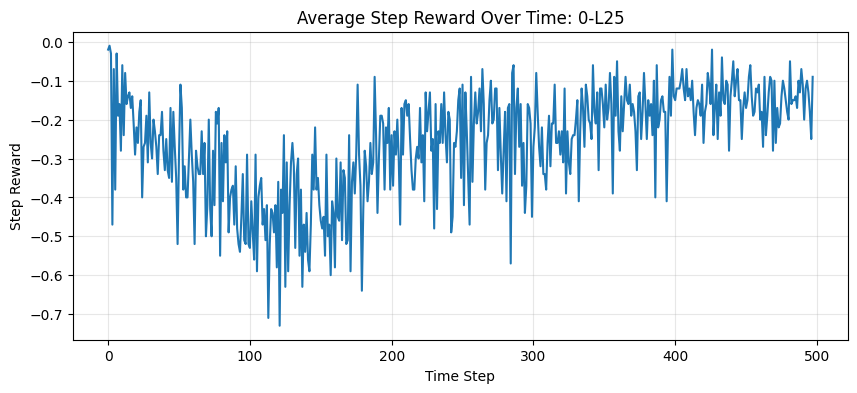

Saved individual attack plot → 0-L25_avg_reward.png


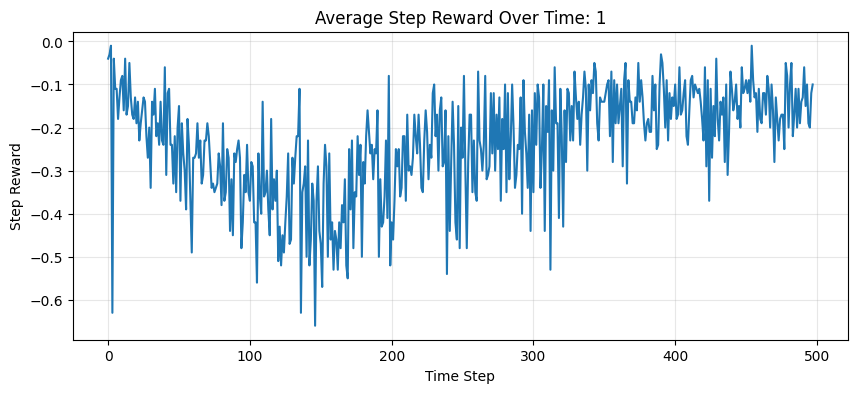

Saved individual attack plot → 1_avg_reward.png


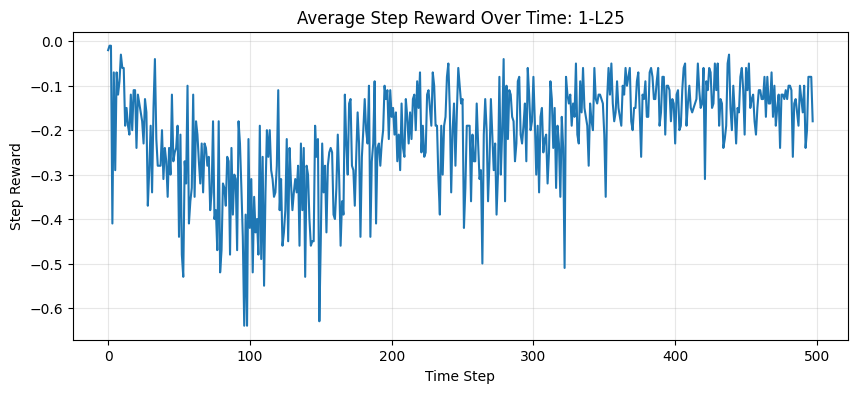

Saved individual attack plot → 1-L25_avg_reward.png


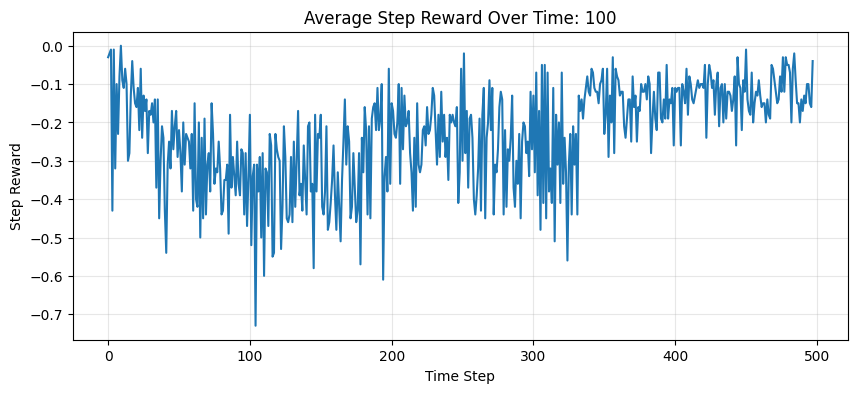

Saved individual attack plot → 100_avg_reward.png


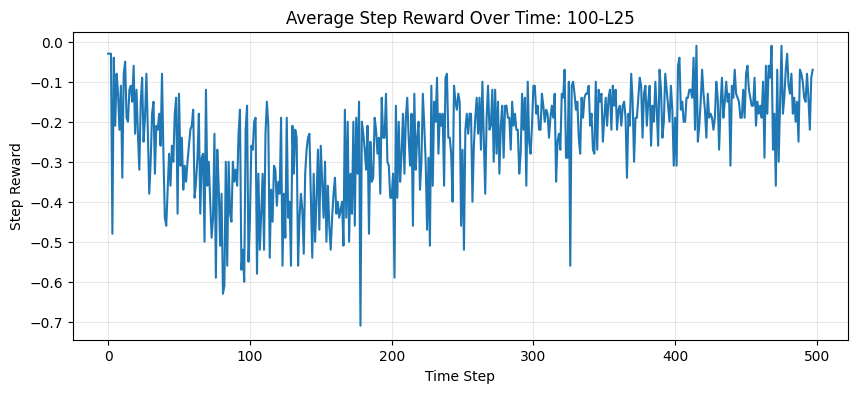

Saved individual attack plot → 100-L25_avg_reward.png


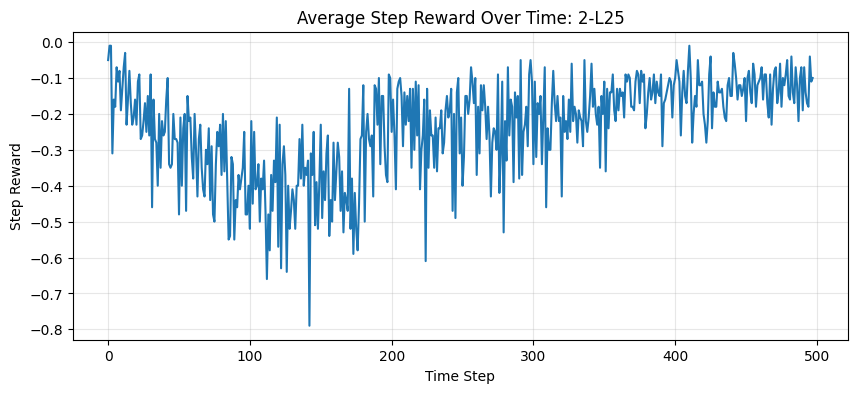

Saved individual attack plot → 2-L25_avg_reward.png


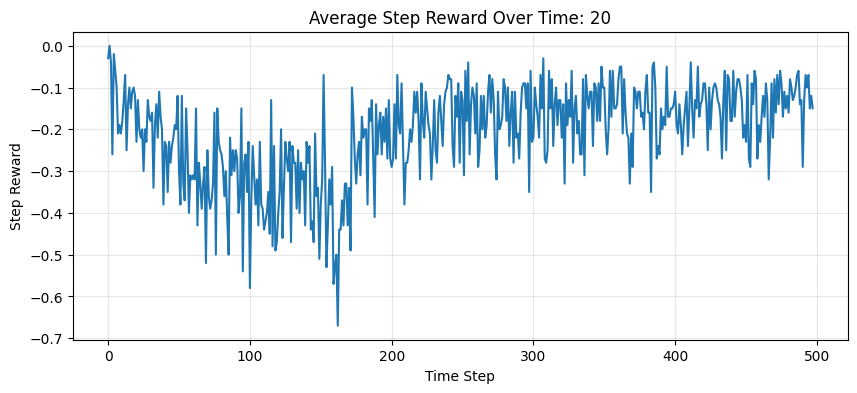

Saved individual attack plot → 20_avg_reward.png


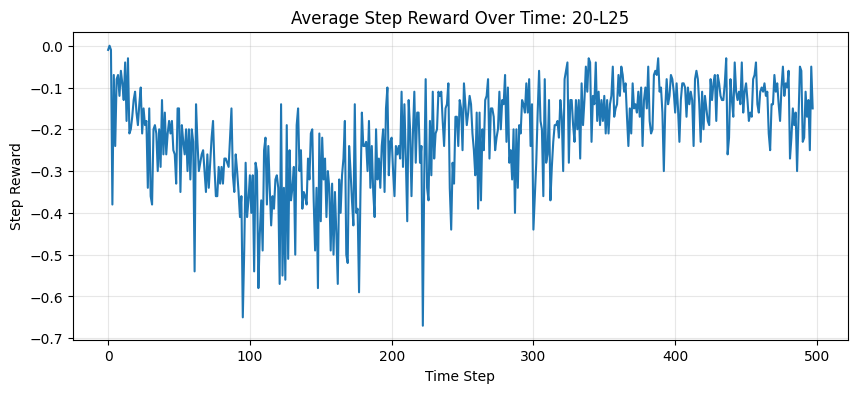

Saved individual attack plot → 20-L25_avg_reward.png


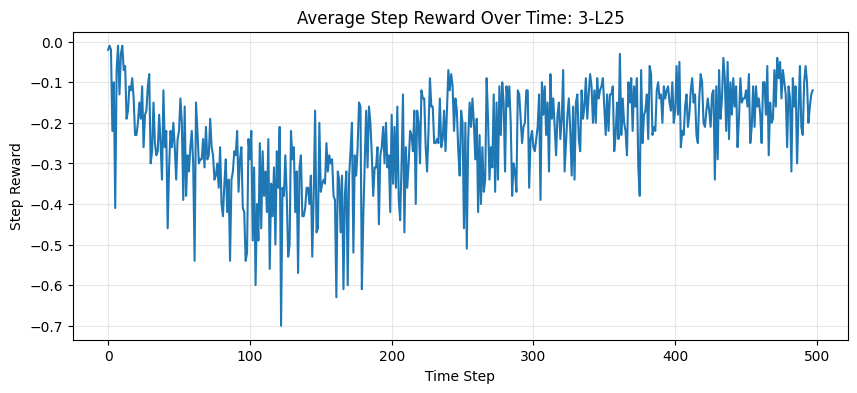

Saved individual attack plot → 3-L25_avg_reward.png


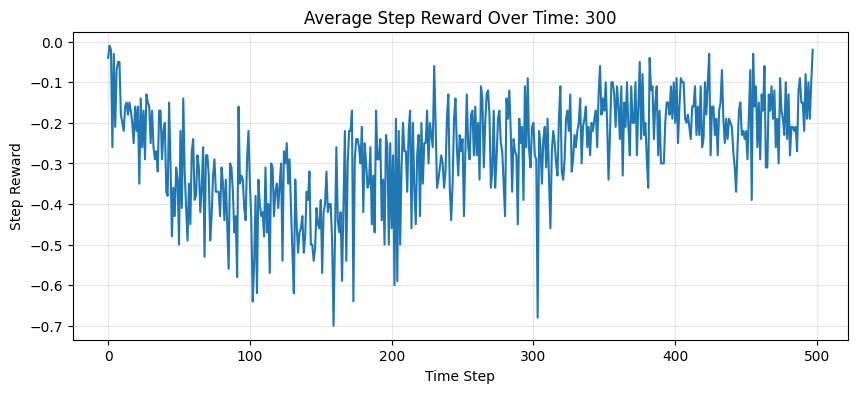

Saved individual attack plot → 300_avg_reward.png


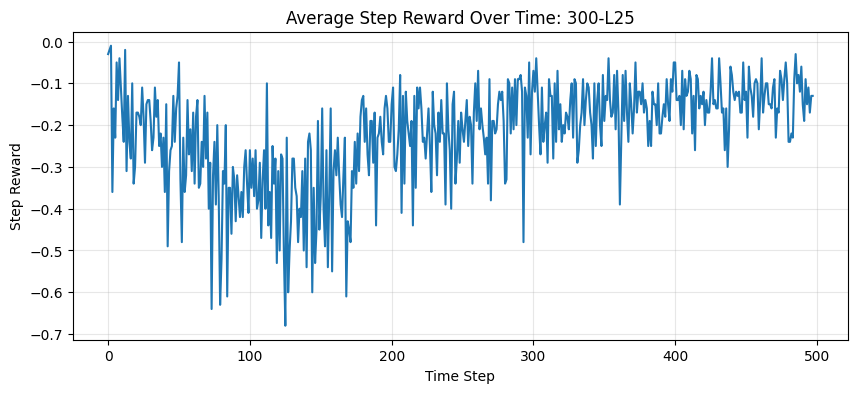

Saved individual attack plot → 300-L25_avg_reward.png


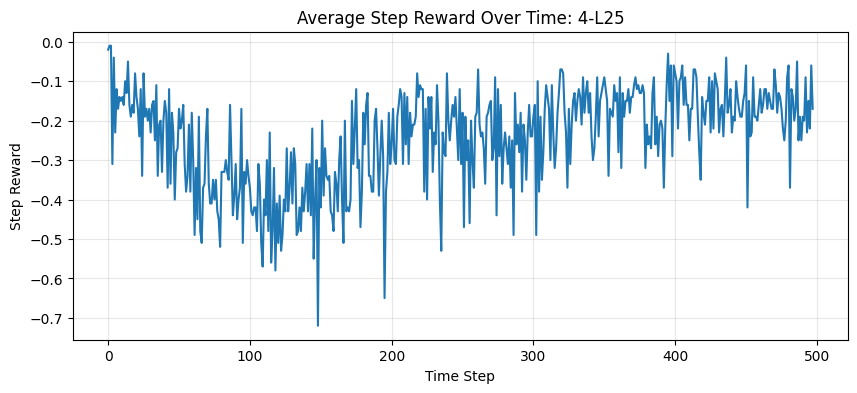

Saved individual attack plot → 4-L25_avg_reward.png


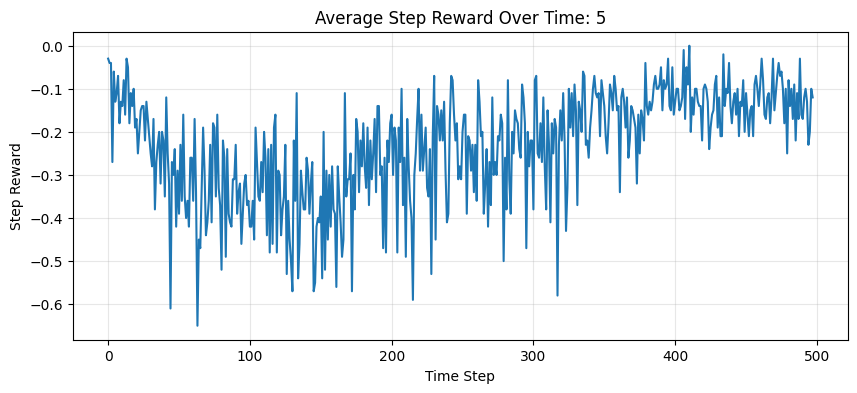

Saved individual attack plot → 5_avg_reward.png


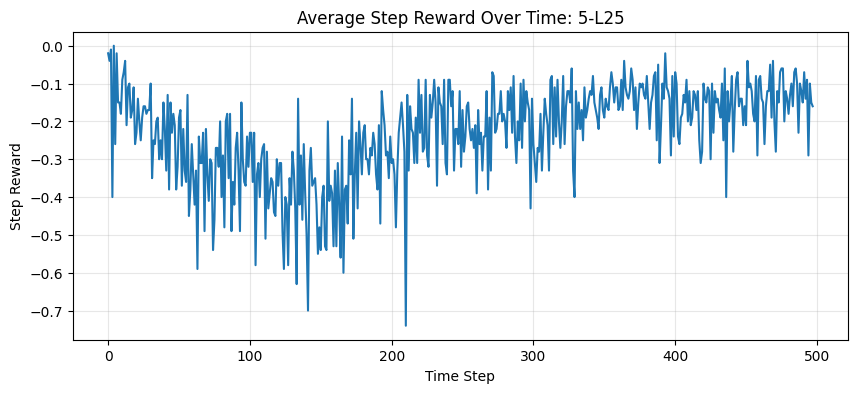

Saved individual attack plot → 5-L25_avg_reward.png


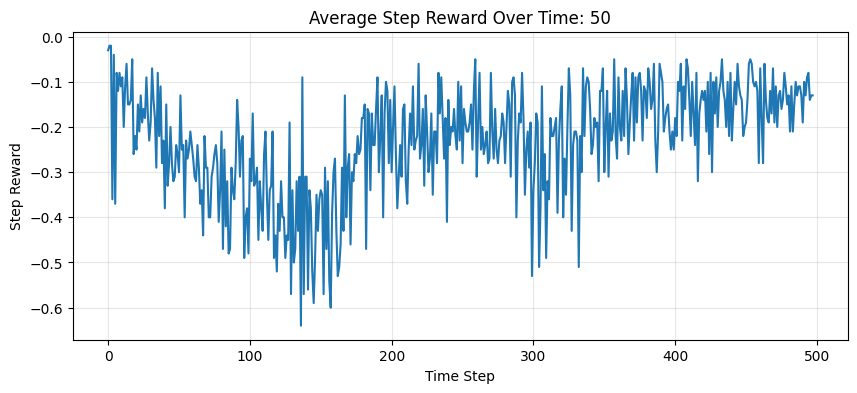

Saved individual attack plot → 50_avg_reward.png


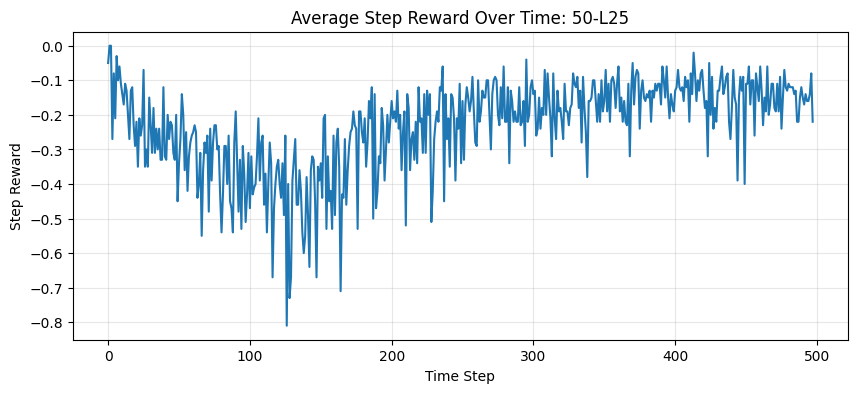

Saved individual attack plot → 50-L25_avg_reward.png


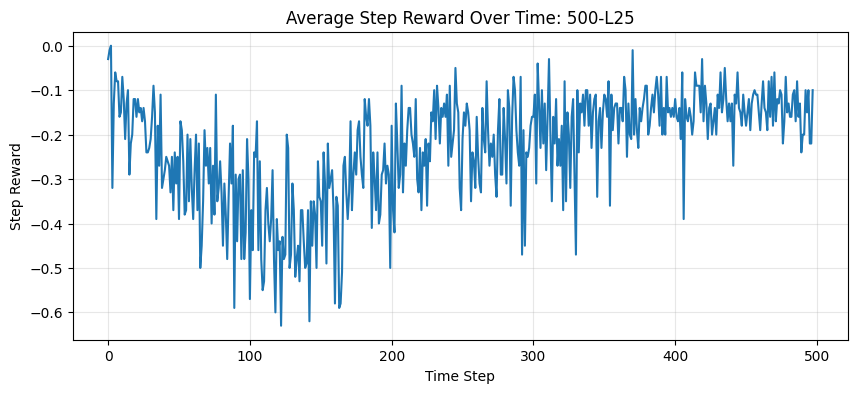

Saved individual attack plot → 500-L25_avg_reward.png


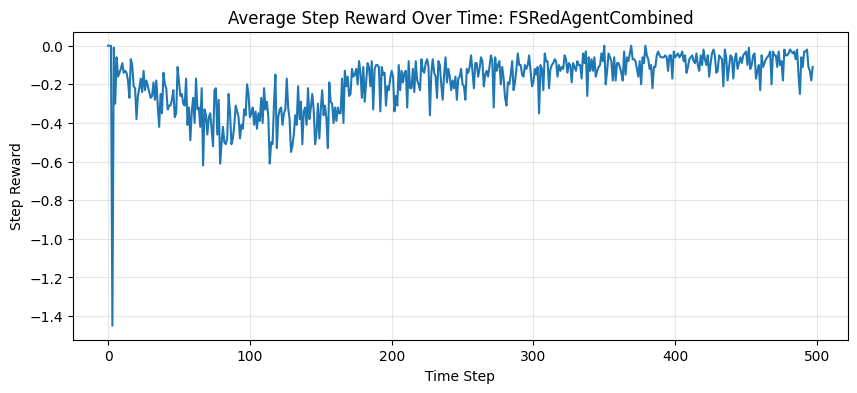

Saved individual attack plot → FSRedAgentCombined_avg_reward.png


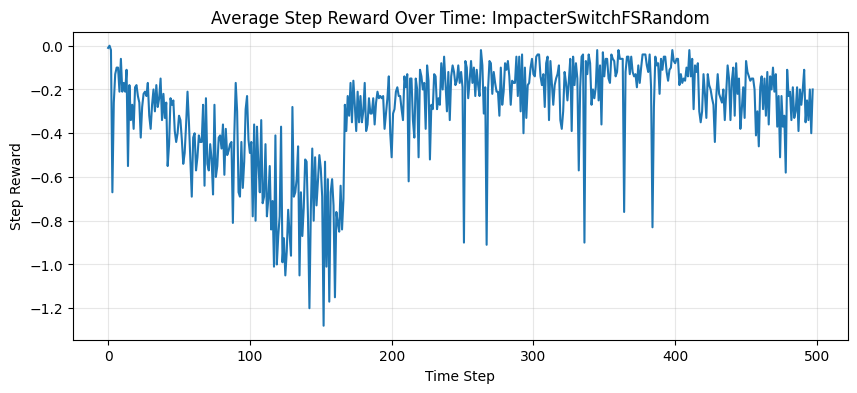

Saved individual attack plot → ImpacterSwitchFSRandom_avg_reward.png


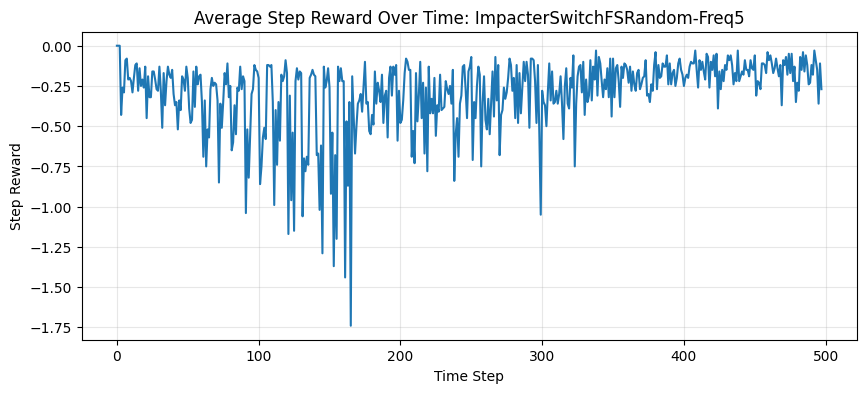

Saved individual attack plot → ImpacterSwitchFSRandom-Freq5_avg_reward.png


In [13]:

# --------------------------
# MAIN SCRIPT
# --------------------------
ROOT = "."   # root directory

agent_folders = get_agent_folders(ROOT)
print("Detected attack types:")
for f in agent_folders:
    print("  -", os.path.basename(f))

all_attack_curves = []   # store average curves for each attack type
attack_labels = []       # store folder names (attack type names)

# Load and average for each attack type
for folder in agent_folders:
    step_path = os.path.join(folder, "step_rewards.txt")
    curves = load_step_rewards(step_path)

    if len(curves) == 0:
        print(f"WARNING: No curves found in {folder}")
        continue

    avg_curve = average_attack_type(curves)
    all_attack_curves.append(avg_curve)
    attack_labels.append(os.path.basename(folder))

    # -------------------------------------------------------------
    # INDIVIDUAL PLOT FOR EACH ATTACK TYPE
    # -------------------------------------------------------------
    plt.figure(figsize=(10, 4))
    plt.plot(avg_curve)
    plt.title(f"Average Step Reward Over Time: {os.path.basename(folder)}")
    plt.xlabel("Time Step")
    plt.ylabel("Step Reward")
    plt.grid(True, alpha=0.3)
    out_file = f"{os.path.basename(folder)}_avg_reward.png"
    plt.show()

    # plt.savefig(out_file, dpi=180)
    plt.close()
    print(f"Saved individual attack plot → {out_file}")



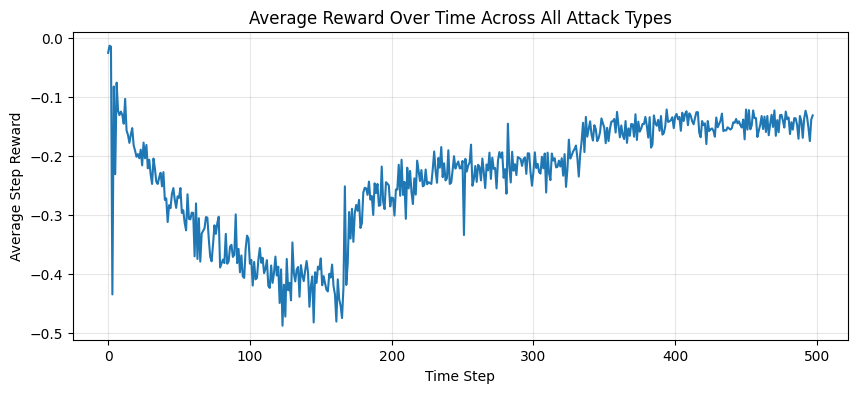

Saved global average plot → global_avg_reward.png


In [14]:

# -------------------------------------------------------------
# GLOBAL AVERAGE ACROSS ATTACK TYPES
# -------------------------------------------------------------
if len(all_attack_curves) > 0:
    all_attack_curves = np.array(all_attack_curves)
    global_avg = np.mean(all_attack_curves, axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(global_avg)
    plt.title("Average Reward Over Time Across All Attack Types")
    plt.xlabel("Time Step")
    plt.ylabel("Average Step Reward")
    plt.grid(True, alpha=0.3)
    plt.show()
    # plt.savefig("global_avg_reward.png", dpi=180)
    plt.close()
    
    print("Saved global average plot → global_avg_reward.png")

else:
    print("No attack curves detected. Nothing plotted.")


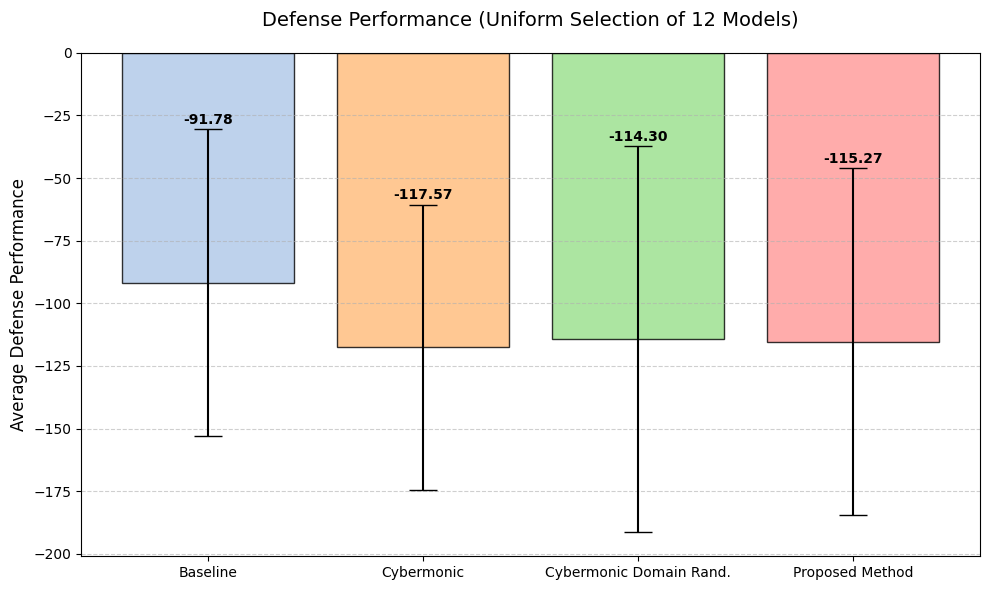

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def calculate_mixture_stats(means_list, stds_list):
    """
    Calculates the mean and std of a uniform mixture of distributions.
    """
    means = np.array(means_list)
    stds = np.array(stds_list)
    
    # 1. The combined mean is the average of the individual means
    mix_mean = np.mean(means)
    
    # 2. The combined variance = (Average of individual variances) + (Variance of the means)
    # This accounts for both the error within models and the spread between models.
    mix_var = np.mean(stds**2) + np.var(means)
    mix_std = np.sqrt(mix_var)
    
    return mix_mean, mix_std

# --- DATA ENTRY ---
# Replace these lists with your 12 values for each method
data_raw = {
    'Baseline': {
        'means': [-13.98, -111.17, -137.19, -134.44, -99.84, -45.59, -71.76, -62.26, -75.36, -99.45, -82.78, -167.52],
        'stds':  [4.12, 29.54, 33.63, 46.76, 63.85, 34.37, 48.75, 36.02, 55.57, 64.16, 59.50, 34.55]
    },
    'Cybermonic': {
        'means': [-37.90, -123.30, -171.85, -158.00, -161.00, -79.62, -85.31, -75.18, -109.78, -106.82, -130.51, -171.58],
        'stds':  [7.41, 18.03, 32.85, 31.43, 79.97, 31.26, 43.33, 33.36, 34.07, 48.57, 33.47, 32.22]
    },
    'Cybermonic Domain Rand.': {
        'means': [-21.88, -112.03, -153.60, -152.41, -241.85, -88.81, -73.82, -88.57, -100.61, -82.18, -100.00, -155.88],
        'stds':  [6.23, 27.09, 42.72, 43.65, 156.28, 25.56, 44.27, 22.38, 22.87, 49.98, 33.85, 34.05]
    },
    
    'Proposed Method': {
        'means': [-14.08, -114.70, -191.48, -189.87, -148.05, -75.31, -79.73, -75.31, -94.07, -106.46, -103.59, -190.58],
        'stds':  [5.58, 28.37, 41.13, 45.82, 80.62, 36.54, 41.01, 40.17, 49.69, 54.80, 38.07, 35.02]
    }
}

# --- CALCULATIONS ---
methods = []
final_means = []
final_stds = []

for method, stats in data_raw.items():
    mu, sigma = calculate_mixture_stats(stats['means'], stats['stds'])
    methods.append(method)
    final_means.append(mu)
    final_stds.append(sigma)

# --- PLOTTING ---
plt.figure(figsize=(10, 6))
colors = ['#aec7e8', '#ffbb78', '#98df8a', '#ff9896']

bars = plt.bar(methods, final_means, yerr=final_stds, capsize=10, 
               color=colors, edgecolor='black', alpha=0.8)

# Add numeric labels
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + final_stds[i] + 1, 
             f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Average Defense Performance', fontsize=12)
plt.title('Defense Performance (Uniform Selection of 12 Models)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.ylim(0, max(final_means) + max(final_stds) + 20)

plt.tight_layout()
plt.show()

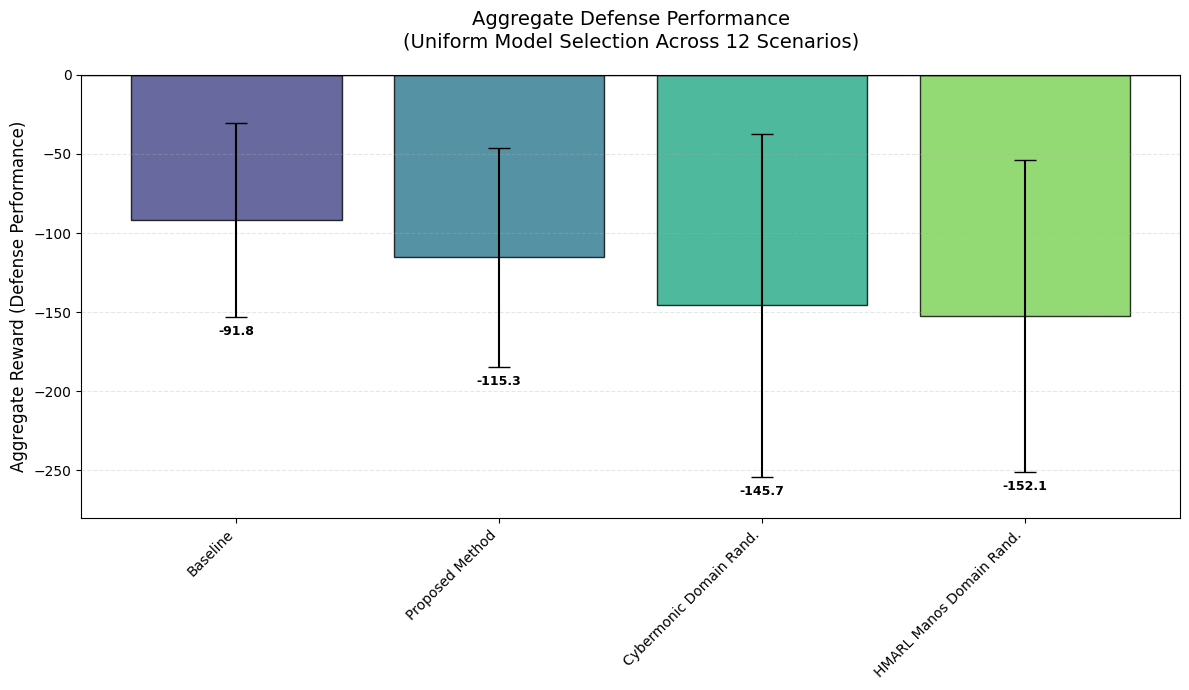

Method                         | Mean       | Std       
-------------------------------------------------------
Baseline                       | -91.78     | 61.24     
Proposed Method                | -115.27    | 69.15     
Cybermonic Domain Rand.        | -145.68    | 108.35    
HMARL Manos Domain Rand.       | -152.13    | 98.56     


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    """
    Calculates the mean and std of a uniform mixture of distributions.
    mix_var = Mean of Variances + Variance of Means
    """
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    """Helper to parse raw mean ± std text into a matrix."""
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    # Reshape into [rows][columns]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# --- DATA RAW STRINGS ---
# text_group_1 = """
# -13.98 ± 4.12, -37.9 ± 7.41, -18.17 ± 7.92, -21.88 ± 0.0, -14.08 ± 5.58
# -111.17 ± 29.54, -123.3 ± 18.03, -134.93 ± 29.56, -112.03 ± 27.09, -114.70 ± 28.37
# -137.19 ± 33.63, -171.85 ± 32.85, -214.16 ± 48.01, -153.6 ± 42.72, -191.48 ± 41.13
# -134.44 ± 46.76, -158 ± 31.43, -223.98 ± 51.61, -152.41 ± 43.65, -189.87 ± 45.82
# -99.84 ± 63.85, -161 ± 79.97, -305.26 ± 218.07, -241.85 ± 156.28, -148.05 ± 80.62
# -45.59 ± 34.37, -79.62 ± 31.26, -70.06 ± 43.88, -88.81 ± 25.56, -75.31 ± 36.54
# -71.76 ± 48.75, -85.31 ± 43.33, -86.24 ± 45.48, -73.82 ± 44.27, -79.73 ± 41.01
# -62.26 ± 36.02, -75.18 ± 33.36, -86.40 ± 45.17, -88.57 ± 22.38, -75.31 ± 40.17
# -75.36 ± 55.57, -109.78 ± 34.07, -132.45 ± 47.71, -100.61 ± 22.87, -94.07 ± 49.69
# -99.45 ± 64.16, -106.82 ± 48.57, -133.58 ± 52.82, -82.18 ± 49.98, -106.46 ± 54.80
# -82.78 ± 59.50, -130.51 ± 33.47, -124.58 ± 50.18, -100 ± 33.85, -103.59 ± 38.07
# -167.52 ± 34.55, -171.58 ± 32.22, -218.36 ± 48.07, -155.88 ± 34.05, -190.58 ± 35.02
# """

text_group_1 = """
-13.98 ± 4.12,  -18.17 ± 7.92,  -14.08 ± 5.58
-111.17 ± 29.54, -134.93 ± 29.56,  -114.70 ± 28.37
-137.19 ± 33.63,  -214.16 ± 48.01,  -191.48 ± 41.13
-134.44 ± 46.76,  -223.98 ± 51.61,  -189.87 ± 45.82
-99.84 ± 63.85, -305.26 ± 218.07, -148.05 ± 80.62
-45.59 ± 34.37,  -70.06 ± 43.88,  -75.31 ± 36.54
-71.76 ± 48.75,  -86.24 ± 45.48,  -79.73 ± 41.01
-62.26 ± 36.02,  -86.40 ± 45.17,  -75.31 ± 40.17
-75.36 ± 55.57,  -132.45 ± 47.71, -94.07 ± 49.69
-99.45 ± 64.16, -133.58 ± 52.82,  -106.46 ± 54.80
-82.78 ± 59.50,  -124.58 ± 50.18, -103.59 ± 38.07
-167.52 ± 34.55,  -218.36 ± 48.07,  -190.58 ± 35.02
"""

text_group_2 = """
0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
-161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
-241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
-233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
-187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
-118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
-107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
-94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
-146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
-134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
-141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
-259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
"""

# Parse matrices
rows1 = parse_table_data(text_group_1, 3)
# rows1 = parse_table_data(text_group_1, 5)
rows2 = parse_table_data(text_group_2, 4)

# Organize into method dictionaries
methods_data = {
    'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
    # 'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    'Cybermonic Domain Rand.': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    # 'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
    'Proposed Method': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
    # 'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
    'HMARL Manos Domain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
    # 'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
    # 'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
    # 'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
}

# --- PROCESS STATISTICS ---
results = []
for name, data in methods_data.items():
    mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
    results.append({'name': name, 'mean': mu, 'std': sigma})

# Sort for the plot (Higher/Less Negative is Better)
results.sort(key=lambda x: x['mean'], reverse=True)

names = [r['name'] for r in results]
means = [r['mean'] for r in results]
stds = [r['std'] for r in results]

# --- PLOTTING ---
plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))

bars = plt.bar(names, means, yerr=stds, capsize=8, color=colors, edgecolor='black', alpha=0.8)

plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Aggregate Reward (Defense Performance)', fontsize=12)
plt.title('Aggregate Defense Performance\n(Uniform Model Selection Across 12 Scenarios)', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim([-280, 0])
# Add value labels
for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - stds[i] - 5, 
             f'{yval:.1f}', ha='center', va='top', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary to console
print(f"{'Method':<30} | {'Mean':<10} | {'Std':<10}")
print("-" * 55)
for r in results:
    print(f"{r['name']:<30} | {r['mean']:<10.2f} | {r['std']:<10.2f}")

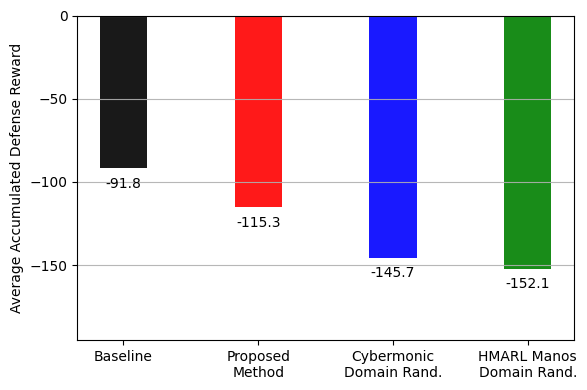

Method                         | Mean       | Std       
-------------------------------------------------------
Baseline                       | -91.78     | 61.24     
Proposed
Method                | -115.27    | 69.15     
Cybermonic
Domain Rand.        | -145.68    | 108.35    
HMARL Manos
Domain Rand.       | -152.13    | 98.56     


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    """
    Calculates the mean and std of a uniform mixture of distributions.
    mix_var = Mean of Variances + Variance of Means
    """
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    """Helper to parse raw mean ± std text into a matrix."""
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

text_group_1 = """
-13.98 ± 4.12,  -18.17 ± 7.92,  -14.08 ± 5.58
-111.17 ± 29.54, -134.93 ± 29.56,  -114.70 ± 28.37
-137.19 ± 33.63,  -214.16 ± 48.01,  -191.48 ± 41.13
-134.44 ± 46.76,  -223.98 ± 51.61,  -189.87 ± 45.82
-99.84 ± 63.85, -305.26 ± 218.07, -148.05 ± 80.62
-45.59 ± 34.37,  -70.06 ± 43.88,  -75.31 ± 36.54
-71.76 ± 48.75,  -86.24 ± 45.48,  -79.73 ± 41.01
-62.26 ± 36.02,  -86.40 ± 45.17,  -75.31 ± 40.17
-75.36 ± 55.57,  -132.45 ± 47.71, -94.07 ± 49.69
-99.45 ± 64.16, -133.58 ± 52.82,  -106.46 ± 54.80
-82.78 ± 59.50,  -124.58 ± 50.18, -103.59 ± 38.07
-167.52 ± 34.55,  -218.36 ± 48.07,  -190.58 ± 35.02
"""

text_group_2 = """
0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
-161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
-241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
-233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
-187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
-118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
-107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
-94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
-146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
-134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
-141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
-259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
"""

# Parse matrices
rows1 = parse_table_data(text_group_1, 3)
rows2 = parse_table_data(text_group_2, 4)

# Organize into method dictionaries
methods_data = {
    'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
    'Proposed\nMethod': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
    'Cybermonic\nDomain Rand.': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    'HMARL Manos\nDomain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
}

# Process statistics
results = []
for name, data in methods_data.items():
    mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
    results.append({'name': name, 'mean': mu, 'std': sigma})

# Sort for the plot
# results.sort(key=lambda x: x['mean'], reverse=True)

names = [r['name'] for r in results]
means = [r['mean'] for r in results]
stds = [r['std'] for r in results]

# Plotting with style matching earlier plot
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['black', 'red', 'blue', 'green']

bars = ax.bar(names, means, color=colors[:len(names)], alpha=0.9, width=0.35)
# bars = ax.bar(names, means, alpha=0.9, edgecolor='black', width=0.25)

ax.set_ylabel('Average Accumulated Defense Reward')
ax.set_ylim([-195, 0])
ax.set_yticks([0, -50, -100, -150])
ax.grid(True, alpha=0.9, axis='y')

# Add value labels on bars
for bar, val in zip(bars, means):
    height = bar.get_height() - 5
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height >= 0 else 'top')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print summary
print(f"{'Method':<30} | {'Mean':<10} | {'Std':<10}")
print("-" * 55)
for r in results:
    print(f"{r['name']:<30} | {r['mean']:<10.2f} | {r['std']:<10.2f}")

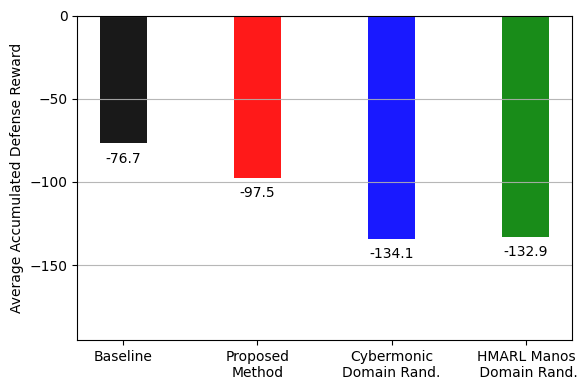

Method                         | Mean       | Std       
-------------------------------------------------------
Baseline                       | -76.72     | 56.02     
Proposed
Method                | -97.50     | 56.11     
Cybermonic
Domain Rand.        | -134.08    | 119.06    
HMARL Manos
 Domain Rand.      | -132.92    | 82.69     


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    """Calculates mean and std for a uniform mixture of distributions."""
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    # Variance mixture formula: Mean of Variances + Variance of Means
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# --- DATA SOURCES ---
# text_group_1 = """
# -13.98 ± 4.12, -37.9 ± 7.41, -18.17 ± 7.92, -21.88 ± 0.0, -14.08 ± 5.58
# -111.17 ± 29.54, -123.3 ± 18.03, -134.93 ± 29.56, -112.03 ± 27.09, -114.70 ± 28.37
# -137.19 ± 33.63, -171.85 ± 32.85, -214.16 ± 48.01, -153.6 ± 42.72, -191.48 ± 41.13
# -134.44 ± 46.76, -158 ± 31.43, -223.98 ± 51.61, -152.41 ± 43.65, -189.87 ± 45.82
# -99.84 ± 63.85, -161 ± 79.97, -305.26 ± 218.07, -241.85 ± 156.28, -148.05 ± 80.62
# -45.59 ± 34.37, -79.62 ± 31.26, -70.06 ± 43.88, -88.81 ± 25.56, -75.31 ± 36.54
# -71.76 ± 48.75, -85.31 ± 43.33, -86.24 ± 45.48, -73.82 ± 44.27, -79.73 ± 41.01
# -62.26 ± 36.02, -75.18 ± 33.36, -86.40 ± 45.17, -88.57 ± 22.38, -75.31 ± 40.17
# -75.36 ± 55.57, -109.78 ± 34.07, -132.45 ± 47.71, -100.61 ± 22.87, -94.07 ± 49.69
# -99.45 ± 64.16, -106.82 ± 48.57, -133.58 ± 52.82, -82.18 ± 49.98, -106.46 ± 54.80
# -82.78 ± 59.50, -130.51 ± 33.47, -124.58 ± 50.18, -100 ± 33.85, -103.59 ± 38.07
# -167.52 ± 34.55, -171.58 ± 32.22, -218.36 ± 48.07, -155.88 ± 34.05, -190.58 ± 35.02
# """

# text_group_2 = """
# 0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
# -161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
# -241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
# -233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
# -187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
# -118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
# -107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
# -94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
# -146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
# -134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
# -141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
# -259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
# """

# Parse matrices
# rows1_full = parse_table_data(text_group_1, 5)
rows1_full = parse_table_data(text_group_1, 3)
rows2_full = parse_table_data(text_group_2, 4)

# SLICE DATA: Rows 5 to 11 (Indices 4 to 10 inclusive)
rows1 = rows1_full[4:11]
rows2 = rows2_full[4:11]

# print(rows1)
# methods_data = {
#     'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
#     'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
#     'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
#     'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
#     'HMARL Manos Domain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
#     'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
#     # 'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
#     # 'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
# }
# Organize into method dictionaries
methods_data = {
    'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
    # 'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    # 'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
    'Proposed\nMethod': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
    # 'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
    'Cybermonic\nDomain Rand.': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    'HMARL Manos\n Domain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
    # 'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
    # 'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
    # 'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
}

# --- STATS ---
results = []
for name, data in methods_data.items():
    mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
    results.append({'name': name, 'mean': mu, 'std': sigma})

# results.sort(key=lambda x: x['mean'], reverse=True)
names = [r['name'] for r in results]
means = [r['mean'] for r in results]
stds = [r['std'] for r in results]

# --- PLOT ---

# Plotting with style matching earlier plot
fig, ax = plt.subplots(figsize=(6, 4))
# colors = ['black', 'blue', 'green', 'red']

bars = ax.bar(names, means, color=colors[:len(names)], alpha=0.9, width=0.35)
# bars = ax.bar(names, means, alpha=0.9, edgecolor='black', width=0.25)
# plt.title('Aggregate Defense Performance (Targeted/Operational Attacks Subset)\nRows 5-11: Impacter to BRestricted', fontsize=14, pad=20)

ax.set_ylabel('Average Accumulated Defense Reward')#, fontsize=12)
ax.set_ylim([-195, 0])
ax.set_yticks([0, -50, -100, -150])
ax.grid(True, alpha=0.9, axis='y')

# Add value labels on bars
for bar, val in zip(bars, means):
    height = bar.get_height() - 5
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height >= 0 else 'top')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"{'Method':<30} | {'Mean':<10} | {'Std':<10}")
print("-" * 55)
for r in results:
    print(f"{r['name']:<30} | {r['mean']:<10.2f} | {r['std']:<10.2f}")

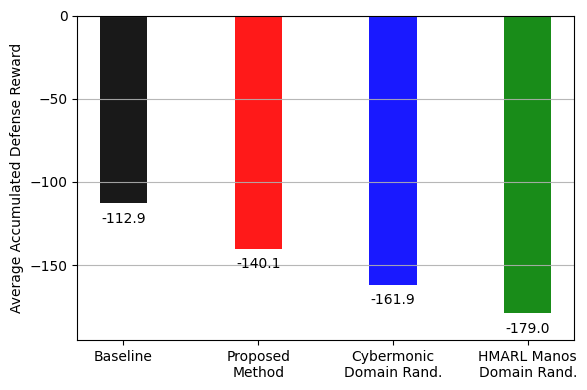

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# --- DATA ENTRY (Full Strings) ---
# ... (Strings text_group_1 and text_group_2 from previous codes) ...

# Parse full matrices
# rows1_full = parse_table_data(text_group_1, 5)
rows1_full = parse_table_data(text_group_1, 3)
rows2_full = parse_table_data(text_group_2, 4)

# SLICE DATA: Indices 0, 1, 2, 3, and 11 (General/Untargeted)
indices_untargeted = [0, 1, 2, 3, 11]
rows1 = [rows1_full[i] for i in indices_untargeted]
rows2 = [rows2_full[i] for i in indices_untargeted]

# methods_data = {
#     'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
#     'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
#     'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
#     'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
#     'HMARL Manos Domain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
#     'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
#     'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
#     'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
# }
methods_data = {
    'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
    # 'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    # 'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
    'Proposed\nMethod': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
    # 'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
    'Cybermonic\nDomain Rand.': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    'HMARL Manos\nDomain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
    # 'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
    # 'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
    # 'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
}
# --- STATS & PLOT ---
results = []
for name, data in methods_data.items():
    mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
    results.append({'name': name, 'mean': mu, 'std': sigma})

# results.sort(key=lambda x: x['mean'], reverse=True)
names = [r['name'] for r in results]
means = [r['mean'] for r in results]
stds = [r['std'] for r in results]


# Plotting with style matching earlier plot
fig, ax = plt.subplots(figsize=(6, 4))
# colors = ['black', 'blue', 'red', 'green']

bars = ax.bar(names, means, color=colors[:len(names)], alpha=0.9, width=0.35)
# bars = ax.bar(names, means, alpha=0.9, edgecolor='black', width=0.25)
# plt.title('Aggregate Performance (Aggressive Attacks)', fontsize=14, pad=20)
# 
ax.set_ylabel('Average Accumulated Defense Reward')#, fontsize=12)
ax.set_ylim([-195, 0])
ax.set_yticks([0, -50, -100, -150])
ax.grid(True, alpha=0.9, axis='y')

# Add value labels on bars
for bar, val in zip(bars, means):
    height = bar.get_height() - 5
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height >= 0 else 'top')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


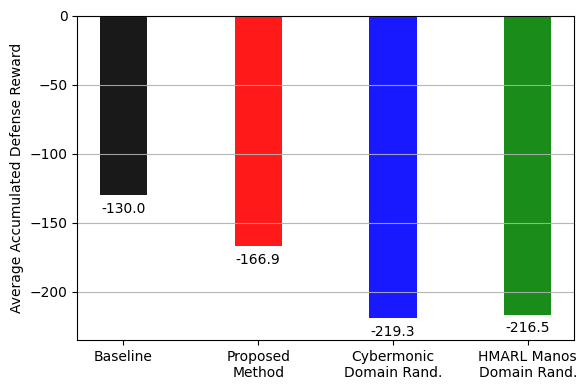

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# --- DATA ENTRY (Full Strings) ---
# ... (Strings text_group_1 and text_group_2 from previous codes) ...

# Parse full matrices
# rows1_full = parse_table_data(text_group_1, 5)
rows1_full = parse_table_data(text_group_1, 3)
rows2_full = parse_table_data(text_group_2, 4)

# SLICE DATA: Indices 0, 1, 2, 3, and 11 (General/Untargeted)
indices_untargeted = [1, 2, 3, 4, 11]
rows1 = [rows1_full[i] for i in indices_untargeted]
rows2 = [rows2_full[i] for i in indices_untargeted]

# methods_data = {
#     'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
#     'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
#     'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
#     'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
#     'HMARL Manos Domain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
#     'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
#     'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
#     'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
# }
methods_data = {
    'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
    # 'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    # 'Cybermonic Domain Rand.': {'means': [r[3][0] for r in rows1], 'stds': [r[3][1] for r in rows1]},
    'Proposed\nMethod': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
    # 'Proposed Method': {'means': [r[4][0] for r in rows1], 'stds': [r[4][1] for r in rows1]},
    'Cybermonic\nDomain Rand.': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
    'HMARL Manos\nDomain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
    # 'HMARL Manos Only FSRed': {'means': [r[1][0] for r in rows2], 'stds': [r[1][1] for r in rows2]},
    # 'IPPO Davide Only FSRed': {'means': [r[2][0] for r in rows2], 'stds': [r[2][1] for r in rows2]},
    # 'MAPPO Davide Only FSRed': {'means': [r[3][0] for r in rows2], 'stds': [r[3][1] for r in rows2]}
}
# --- STATS & PLOT ---
results = []
for name, data in methods_data.items():
    mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
    results.append({'name': name, 'mean': mu, 'std': sigma})

# results.sort(key=lambda x: x['mean'], reverse=True)
names = [r['name'] for r in results]
means = [r['mean'] for r in results]
stds = [r['std'] for r in results]


# Plotting with style matching earlier plot
fig, ax = plt.subplots(figsize=(6, 4))
# colors = ['black', 'blue', 'red', 'green']

bars = ax.bar(names, means, color=colors[:len(names)], alpha=0.9, width=0.35)
# bars = ax.bar(names, means, alpha=0.9, edgecolor='black', width=0.25)
# plt.title('Aggregate Performance (Untargeted/General Attacks)', fontsize=14, pad=20)
# 
ax.set_ylabel('Average Accumulated Defense Reward')#, fontsize=12)
ax.set_ylim([-235, 0])
ax.set_yticks([0, -50, -100, -150, -200])
ax.grid(True, alpha=0.9, axis='y')

# Add value labels on bars
for bar, val in zip(bars, means):
    height = bar.get_height() - 5
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom' if height >= 0 else 'top')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


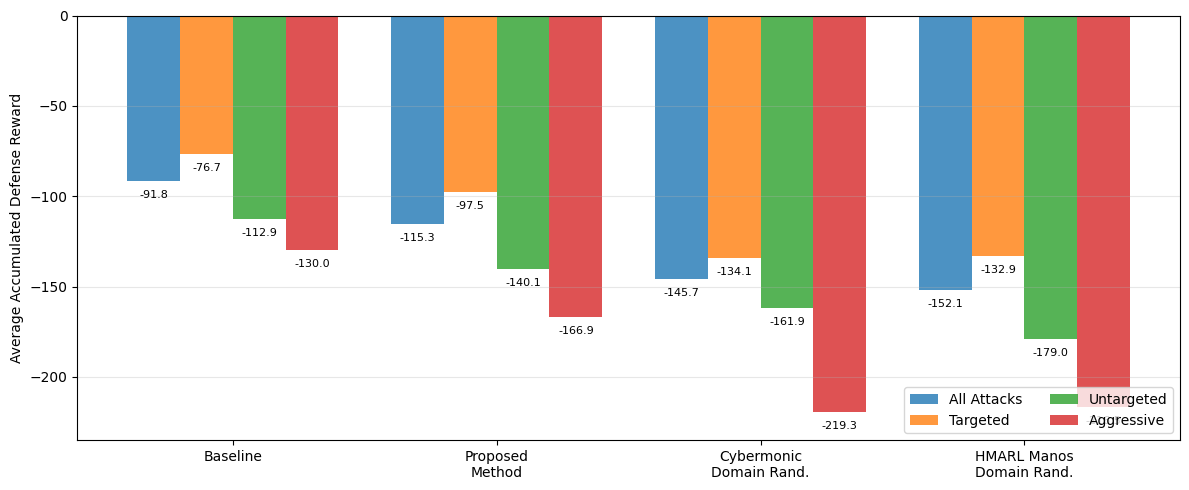

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# Same text_group_1 and text_group_2 from previous code
text_group_1 = """
-13.98 ± 4.12,  -18.17 ± 7.92,  -14.08 ± 5.58
-111.17 ± 29.54, -134.93 ± 29.56,  -114.70 ± 28.37
-137.19 ± 33.63,  -214.16 ± 48.01,  -191.48 ± 41.13
-134.44 ± 46.76,  -223.98 ± 51.61,  -189.87 ± 45.82
-99.84 ± 63.85, -305.26 ± 218.07, -148.05 ± 80.62
-45.59 ± 34.37,  -70.06 ± 43.88,  -75.31 ± 36.54
-71.76 ± 48.75,  -86.24 ± 45.48,  -79.73 ± 41.01
-62.26 ± 36.02,  -86.40 ± 45.17,  -75.31 ± 40.17
-75.36 ± 55.57,  -132.45 ± 47.71, -94.07 ± 49.69
-99.45 ± 64.16, -133.58 ± 52.82,  -106.46 ± 54.80
-82.78 ± 59.50,  -124.58 ± 50.18, -103.59 ± 38.07
-167.52 ± 34.55,  -218.36 ± 48.07,  -190.58 ± 35.02
"""

text_group_2 = """
0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
-161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
-241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
-233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
-187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
-118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
-107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
-94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
-146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
-134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
-141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
-259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
"""

# Parse matrices
rows1_full = parse_table_data(text_group_1, 3)
rows2_full = parse_table_data(text_group_2, 4)

# Define slices for each scenario
all_indices = list(range(12))
targeted_indices = [4, 5, 6, 7, 8, 9, 10]
untargeted_indices = [0, 1, 2, 3, 11]
aggressive_indices = [1, 2, 3, 4, 11]

def compute_method_stats(indices):
    rows1 = [rows1_full[i] for i in indices]
    rows2 = [rows2_full[i] for i in indices]
    
    methods = {
        'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
        'Proposed': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
        'Cybermonic': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
        'HMARL': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
    }
    
    results = {}
    for name, data in methods.items():
        mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
        results[name] = mu
    return results

# Compute stats for all scenarios
all_stats = compute_method_stats(all_indices)
targeted_stats = compute_method_stats(targeted_indices)
untargeted_stats = compute_method_stats(untargeted_indices)
aggressive_stats = compute_method_stats(aggressive_indices)

# Organize data for grouped bar plot
method_names = ['Baseline', 'Proposed\nMethod', 'Cybermonic\nDomain Rand.', 'HMARL Manos\nDomain Rand.']
method_keys = ['Baseline', 'Proposed', 'Cybermonic', 'HMARL']

scenario_data = {
    'All Attacks': [all_stats[k] for k in method_keys],
    'Targeted': [targeted_stats[k] for k in method_keys],
    'Untargeted': [untargeted_stats[k] for k in method_keys],
    'Aggressive': [aggressive_stats[k] for k in method_keys]
}

# Plotting
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(method_names))
width = 0.2
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (scenario, values) in enumerate(scenario_data.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=scenario, color=colors[i], alpha=0.8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height - 5,
                f'{height:.1f}', ha='center', va='top', fontsize=8)

ax.set_ylabel('Average Accumulated Defense Reward')
ax.set_xticks(x)
ax.set_xticklabels(method_names)
ax.set_ylim([-235, 0])
ax.set_yticks([0, -50, -100, -150, -200])
ax.legend(loc='lower right', ncol=2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

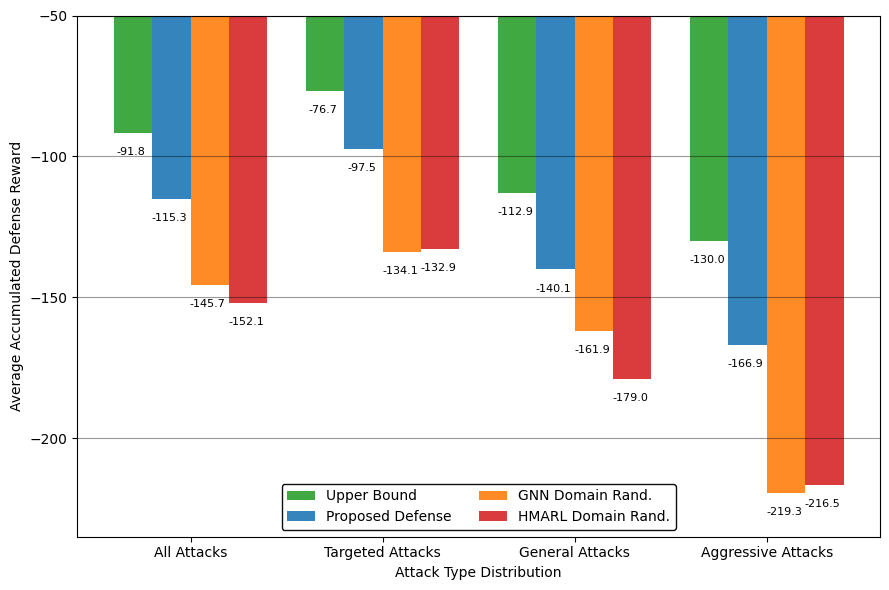

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import re

def calculate_mixture_stats(means, stds):
    m = np.array(means)
    s = np.array(stds)
    mix_mean = np.mean(m)
    mix_var = np.mean(s**2) + np.var(m)
    mix_std = np.sqrt(mix_var)
    return mix_mean, mix_std

def parse_table_data(text, num_cols):
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

text_group_1 = """
-13.98 ± 4.12,  -18.17 ± 7.92,  -14.08 ± 5.58
-111.17 ± 29.54, -134.93 ± 29.56,  -114.70 ± 28.37
-137.19 ± 33.63,  -214.16 ± 48.01,  -191.48 ± 41.13
-134.44 ± 46.76,  -223.98 ± 51.61,  -189.87 ± 45.82
-99.84 ± 63.85, -305.26 ± 218.07, -148.05 ± 80.62
-45.59 ± 34.37,  -70.06 ± 43.88,  -75.31 ± 36.54
-71.76 ± 48.75,  -86.24 ± 45.48,  -79.73 ± 41.01
-62.26 ± 36.02,  -86.40 ± 45.17,  -75.31 ± 40.17
-75.36 ± 55.57,  -132.45 ± 47.71, -94.07 ± 49.69
-99.45 ± 64.16, -133.58 ± 52.82,  -106.46 ± 54.80
-82.78 ± 59.50,  -124.58 ± 50.18, -103.59 ± 38.07
-167.52 ± 34.55,  -218.36 ± 48.07,  -190.58 ± 35.02
"""

text_group_2 = """
0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
-161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
-241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
-233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
-187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
-118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
-107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
-94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
-146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
-134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
-141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
-259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
"""

# Parse matrices
rows1_full = parse_table_data(text_group_1, 3)
rows2_full = parse_table_data(text_group_2, 4)

# Define slices for each scenario
all_indices = list(range(12))
targeted_indices = [4, 5, 6, 7, 8, 9, 10]
untargeted_indices = [0, 1, 2, 3, 11]
aggressive_indices = [1, 2, 3, 4, 11]

def compute_method_stats(indices):
    rows1 = [rows1_full[i] for i in indices]
    rows2 = [rows2_full[i] for i in indices]
    
    methods = {
        'Baseline': {'means': [r[0][0] for r in rows1], 'stds': [r[0][1] for r in rows1]},
        'Proposed Method': {'means': [r[2][0] for r in rows1], 'stds': [r[2][1] for r in rows1]},
        'Cybermonic\nDomain Rand.': {'means': [r[1][0] for r in rows1], 'stds': [r[1][1] for r in rows1]},
        'HMARL Manos\nDomain Rand.': {'means': [r[0][0] for r in rows2], 'stds': [r[0][1] for r in rows2]},
    }
    
    results = {}
    for name, data in methods.items():
        mu, sigma = calculate_mixture_stats(data['means'], data['stds'])
        results[name] = mu
    return results

# Compute stats for all scenarios
all_stats = compute_method_stats(all_indices)
targeted_stats = compute_method_stats(targeted_indices)
untargeted_stats = compute_method_stats(untargeted_indices)
aggressive_stats = compute_method_stats(aggressive_indices)

# Organize data for grouped bar plot
method_names = ['Baseline', 'Proposed Method', 'Cybermonic\nDomain Rand.', 'HMARL Manos\nDomain Rand.']
scenario_names = ['All Attacks', 'Targeted Attacks', 'General Attacks', 'Aggressive Attacks']

# Reorganize data: each method has values across all scenarios
method_data = {
    'Upper Bound': [all_stats['Baseline'], targeted_stats['Baseline'], 
                 untargeted_stats['Baseline'], aggressive_stats['Baseline']],
    'Proposed Defense': [all_stats['Proposed Method'], targeted_stats['Proposed Method'], 
                        untargeted_stats['Proposed Method'], aggressive_stats['Proposed Method']],
    'GNN Domain Rand.': [all_stats['Cybermonic\nDomain Rand.'], targeted_stats['Cybermonic\nDomain Rand.'], 
                                  untargeted_stats['Cybermonic\nDomain Rand.'], aggressive_stats['Cybermonic\nDomain Rand.']],
    'HMARL Domain Rand.': [all_stats['HMARL Manos\nDomain Rand.'], targeted_stats['HMARL Manos\nDomain Rand.'], 
                                   untargeted_stats['HMARL Manos\nDomain Rand.'], aggressive_stats['HMARL Manos\nDomain Rand.']]
}

# Plotting
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(scenario_names))
width = 0.2
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

for i, (method, values) in enumerate(method_data.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=method, color=colors[i], alpha=0.9)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x()-0.01 + bar.get_width()/2., height - 5,
                f'{height:.1f}', ha='center', va='top', fontsize=8)

ax.set_ylabel('Average Accumulated Defense Reward')
ax.set_xlabel('Attack Type Distribution')
ax.set_xticks(x)
ax.set_xticklabels(scenario_names)
ax.set_ylim([-235, -50])
ax.set_yticks([-50, -100, -150, -200])
leg = ax.legend(loc='lower center', ncol=2, edgecolor="black",framealpha=0.95)
leg.get_frame().set_linewidth(1)
ax.grid(True, alpha=0.4, axis='y', color='black')

plt.tight_layout()
plt.savefig("res1.jpg", dpi=300)
plt.show()

[[2.47778774e-13 1.41437718e-09 5.67504212e-13 ... 5.59624019e-02
  2.42797913e-03 8.34042504e-01]
 [5.94203825e-04 3.40069703e-01 4.15583120e-05 ... 2.95888888e-03
  1.85483209e-02 1.74060930e-06]
 [1.75210070e-01 9.09687819e-04 4.74956033e-01 ... 8.80965344e-02
  5.50099796e-03 7.47068894e-16]
 ...
 [1.73729825e-02 1.99572568e-01 1.16544196e-06 ... 5.69949622e-04
  1.02965655e-03 1.36949272e-08]
 [1.05532531e-07 4.72225023e-03 1.51573219e-07 ... 2.15865920e-02
  1.54540642e-01 1.57787642e-20]
 [3.83655145e-04 1.35773083e-01 6.85037733e-01 ... 6.44105515e-02
  3.77303539e-03 1.16548480e-08]]


KeyError: 'Baseline'

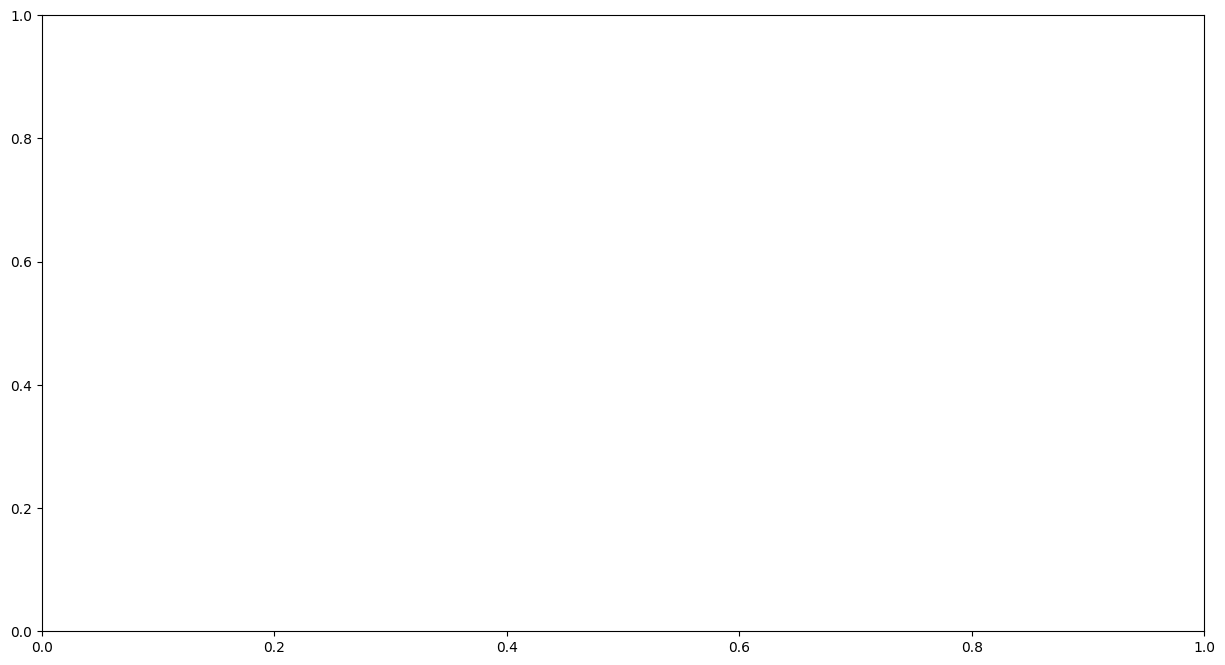

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import re

# 1. PARSING UTILITIES
def parse_table_data(text, num_cols):
    """Extracts mean and std from the text provided."""
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# 2. RAW DATA FROM YOUR TABLE
text_group_1 = """
-13.98 ± 4.12, -37.9 ± 7.41, -18.17 ± 7.92, -21.88 ± 0.0, -14.08 ± 5.58
-111.17 ± 29.54, -123.3 ± 18.03, -134.93 ± 29.56, -112.03 ± 27.09, -114.70 ± 28.37
-137.19 ± 33.63, -171.85 ± 32.85, -214.16 ± 48.01, -153.6 ± 42.72, -191.48 ± 41.13
-134.44 ± 46.76, -158 ± 31.43, -223.98 ± 51.61, -152.41 ± 43.65, -189.87 ± 45.82
-99.84 ± 63.85, -161 ± 79.97, -305.26 ± 218.07, -241.85 ± 156.28, -148.05 ± 80.62
-45.59 ± 34.37, -79.62 ± 31.26, -70.06 ± 43.88, -88.81 ± 25.56, -75.31 ± 36.54
-71.76 ± 48.75, -85.31 ± 43.33, -86.24 ± 45.48, -73.82 ± 44.27, -79.73 ± 41.01
-62.26 ± 36.02, -75.18 ± 33.36, -86.40 ± 45.17, -88.57 ± 22.38, -75.31 ± 40.17
-75.36 ± 55.57, -109.78 ± 34.07, -132.45 ± 47.71, -100.61 ± 22.87, -94.07 ± 49.69
-99.45 ± 64.16, -106.82 ± 48.57, -133.58 ± 52.82, -82.18 ± 49.98, -106.46 ± 54.80
-82.78 ± 59.50, -130.51 ± 33.47, -124.58 ± 50.18, -100 ± 33.85, -103.59 ± 38.07
-167.52 ± 34.55, -171.58 ± 32.22, -218.36 ± 48.07, -155.88 ± 34.05, -190.58 ± 35.02
"""

text_group_2 = """
0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
-161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
-241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
-233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
-187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
-118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
-107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
-94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
-146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
-134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
-141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
-259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
"""

rows1 = parse_table_data(text_group_1, 5)
rows2 = parse_table_data(text_group_2, 4)

# THIS IS THE "DATA" DICTIONARY
methods_data = {
    'Baseline': {'means': np.array([r[0][0] for r in rows1]), 'stds': np.array([r[0][1] for r in rows1])},
    'Cybermonic': {'means': np.array([r[1][0] for r in rows1]), 'stds': np.array([r[1][1] for r in rows1])},
    'Cybermonic Domain Rand.': {'means': np.array([r[3][0] for r in rows1]), 'stds': np.array([r[3][1] for r in rows1])},
    'Proposed Method': {'means': np.array([r[4][0] for r in rows1]), 'stds': np.array([r[4][1] for r in rows1])},
    # 'HMARL Manos Domain Rand.': {'means': np.array([r[0][0] for r in rows2]), 'stds': np.array([r[0][1] for r in rows2])},
    # 'HMARL Manos Only FSRed': {'means': np.array([r[1][0] for r in rows2]), 'stds': np.array([r[1][1] for r in rows2])},
    # 'IPPO Davide Only FSRed': {'means': np.array([r[2][0] for r in rows2]), 'stds': np.array([r[2][1] for r in rows2])},
    # 'MAPPO Davide Only FSRed': {'means': np.array([r[3][0] for r in rows2]), 'stds': np.array([r[3][1] for r in rows2])}
}

# 3. ANALYSIS SETTINGS
alphas = {'Sparse (eta=0.1)': 0.1, 'Medium (eta=1.0)': 1.0, 'Dense (eta=10.0)': 10.0}
n_samples = 2000 # Number of random attacker distributions to draw
num_attacks = 12

# 4. PERFORM SIMULATION
results = {}
for alpha_label, alpha_val in alphas.items():
    results[alpha_label] = {}
    
    # Generate weights from Dirichlet distribution
    # Each row is a probability vector over 12 attack types
    weights = np.random.dirichlet([alpha_val] * num_attacks, n_samples)
    print(weights)
    break
    
    for name, data in methods_data.items():
        mus = data['means']
        sigmas = data['stds']
        
        # Expected reward for each distribution: E[X | w] = sum(w_i * mu_i)
        mixture_means = np.dot(weights, mus)
        
        # Variance for each distribution (Law of Total Variance)
        # Var = E[Var_i] + Var(E_i)
        # Var = sum(w_i * (sigma_i^2 + mu_i^2)) - (sum(w_i * mu_i))^2
        second_moment = np.dot(weights, sigmas**2 + mus**2)
        mixture_vars = second_moment - mixture_means**2
        mixture_stds = np.sqrt(np.maximum(mixture_vars, 0))
        
        results[alpha_label][name] = {
            'avg_reward': np.mean(mixture_means),
            'sensitivity': np.std(mixture_means), # How much avg performance shifts
            'avg_episode_std': np.mean(mixture_stds) # Internal uncertainty
        }

# 5. VISUALIZATION
fig, ax = plt.subplots(figsize=(15, 8))
method_names = list(methods_data.keys())
x_indices = np.arange(len(method_names))
bar_width = 0.25

for i, (alpha_label, alpha_data) in enumerate(results.items()):
    means = [alpha_data[m]['avg_reward'] for m in method_names]
    stds = [alpha_data[m]['avg_episode_std'] for m in method_names]
    
    # Plot bars with Error Bars representing internal uncertainty
    ax.bar(x_indices + (i - 1) * bar_width, means, bar_width, 
           yerr=stds, capsize=4, label=alpha_label, alpha=0.8)

ax.set_ylabel('Defense Reward')
ax.set_title('Robustness to Attacker Focus (Dirichlet Attack Mixtures)')
ax.set_xticks(x_indices)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.legend()
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print Sensitivity Table
print(f"\n{'Method':<30} | {'Regime':<10} | {'Sensitivity':<12}")
print("-" * 60)
for m in method_names:
    for a in alphas.keys():
        print(f"{m:<30} | {a[:8]:<10} | {results[a][m]['sensitivity']:<12.2f}")

[[3.58931834e-09 1.14676568e-08 1.10075307e-05 ... 4.43999830e-06
  1.62697436e-01 8.37173126e-01]
 [1.85928580e-10 1.96918219e-01 6.65751079e-01 ... 3.85915514e-02
  1.72962956e-11 2.62204987e-10]
 [6.17913890e-01 8.96847151e-02 1.35079078e-10 ... 3.21128604e-03
  5.15043833e-06 2.41402304e-04]
 ...
 [1.23519020e-01 1.56473823e-01 3.49940928e-12 ... 4.08110134e-08
  2.36777876e-06 7.19422755e-01]
 [1.00168365e-07 3.05876166e-01 6.58587442e-01 ... 8.74357700e-03
  5.23375309e-03 6.02227412e-06]
 [2.25425834e-01 1.04427232e-02 1.61600243e-11 ... 2.58773717e-03
  3.19563015e-01 1.91525160e-01]]
[[0.28433858 0.02860632 0.06515517 ... 0.11627258 0.17127171 0.19239955]
 [0.03452372 0.01376337 0.21113938 ... 0.04983498 0.4033923  0.13619215]
 [0.13663072 0.01220868 0.06461136 ... 0.08640138 0.04328701 0.46527909]
 ...
 [0.32828493 0.30519289 0.03039849 ... 0.03188164 0.02129967 0.25326005]
 [0.12814014 0.13111765 0.01405593 ... 0.62058762 0.02448654 0.01206258]
 [0.06628659 0.20323344 0.2601

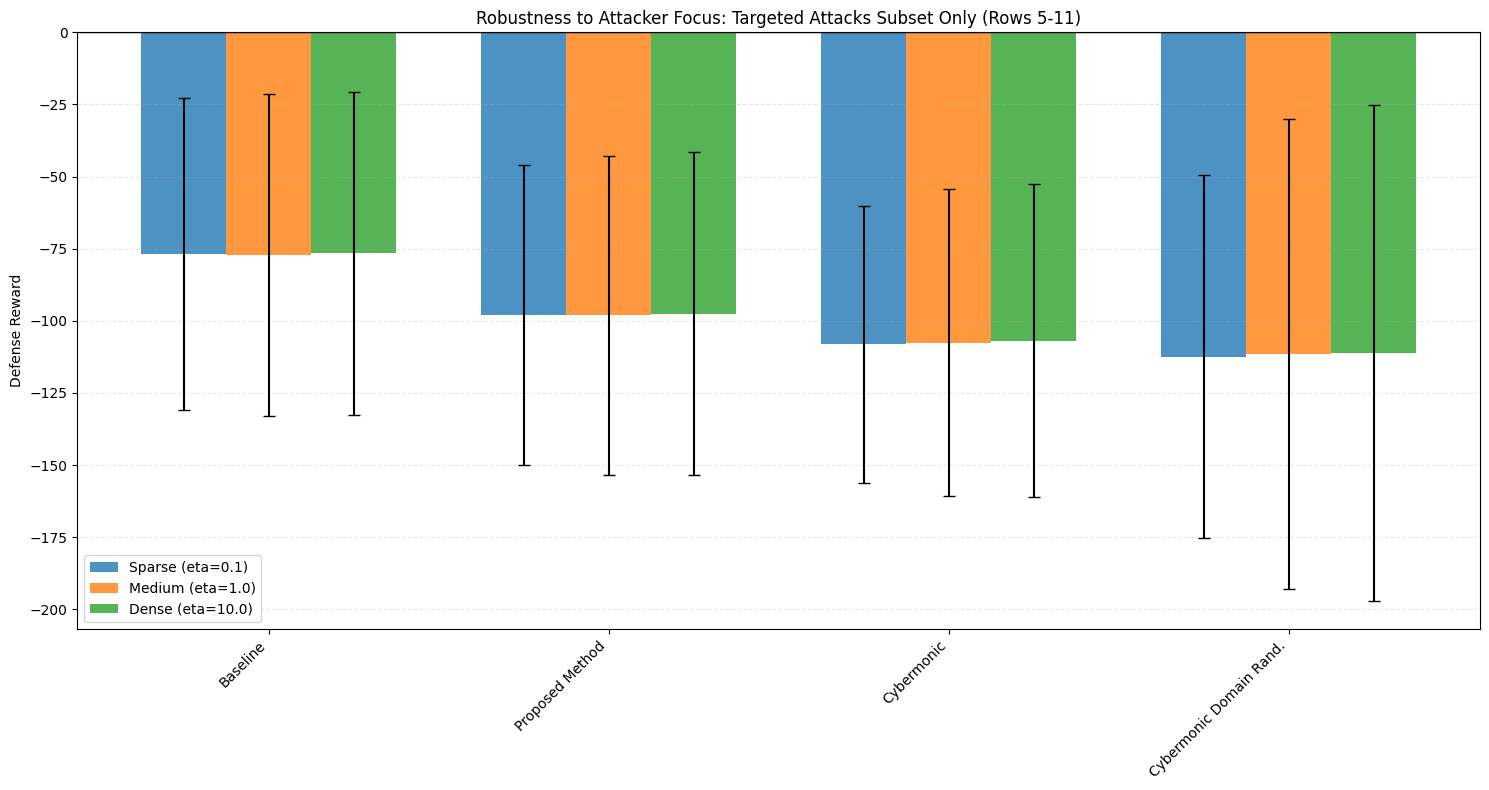


Method                         | Regime     | Sensitivity (Std of Mean)
---------------------------------------------------------------------------
Baseline                       | Sparse (   | 12.92                    
Baseline                       | Medium (   | 6.17                     
Baseline                       | Dense (e   | 2.23                     
Proposed Method                | Sparse (   | 18.11                    
Proposed Method                | Medium (   | 8.16                     
Proposed Method                | Dense (e   | 2.71                     
Cybermonic                     | Sparse (   | 21.58                    
Cybermonic                     | Medium (   | 9.82                     
Cybermonic                     | Dense (e   | 3.08                     
Cybermonic Domain Rand.        | Sparse (   | 42.76                    
Cybermonic Domain Rand.        | Medium (   | 19.24                    
Cybermonic Domain Rand.        | Dense (e   | 6.03         

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import re

# 1. PARSING UTILITIES
def parse_table_data(text, num_cols):
    pattern = re.compile(r"(-?\d+\.?\d*)\s*±\s*(\d+\.?\d*)?")
    matches = pattern.findall(text)
    data = [(float(m), float(s) if s else 0.0) for m, s in matches]
    return [data[i : i + num_cols] for i in range(0, len(data), num_cols)]

# 2. RAW DATA
text_group_1 = """
-13.98 ± 4.12, -37.9 ± 7.41, -18.17 ± 7.92, -21.88 ± 0.0, -14.08 ± 5.58
-111.17 ± 29.54, -123.3 ± 18.03, -134.93 ± 29.56, -112.03 ± 27.09, -114.70 ± 28.37
-137.19 ± 33.63, -171.85 ± 32.85, -214.16 ± 48.01, -153.6 ± 42.72, -191.48 ± 41.13
-134.44 ± 46.76, -158 ± 31.43, -223.98 ± 51.61, -152.41 ± 43.65, -189.87 ± 45.82
-99.84 ± 63.85, -161 ± 79.97, -305.26 ± 218.07, -241.85 ± 156.28, -148.05 ± 80.62
-45.59 ± 34.37, -79.62 ± 31.26, -70.06 ± 43.88, -88.81 ± 25.56, -75.31 ± 36.54
-71.76 ± 48.75, -85.31 ± 43.33, -86.24 ± 45.48, -73.82 ± 44.27, -79.73 ± 41.01
-62.26 ± 36.02, -75.18 ± 33.36, -86.40 ± 45.17, -88.57 ± 22.38, -75.31 ± 40.17
-75.36 ± 55.57, -109.78 ± 34.07, -132.45 ± 47.71, -100.61 ± 22.87, -94.07 ± 49.69
-99.45 ± 64.16, -106.82 ± 48.57, -133.58 ± 52.82, -82.18 ± 49.98, -106.46 ± 54.80
-82.78 ± 59.50, -130.51 ± 33.47, -124.58 ± 50.18, -100 ± 33.85, -103.59 ± 38.07
-167.52 ± 34.55, -171.58 ± 32.22, -218.36 ± 48.07, -155.88 ± 34.05, -190.58 ± 35.02
"""

text_group_2 = """
0 ± 0.0, 0 ± 0.0, -301.63 ± 47.82, -242.4 ± 37.53
-161.22 ± 44.06, -194.46 ± 47.53, -478.42 ± 61.26, -421.38 ± 79.02
-241.02 ± 54.79, -281.12 ± 60.56, -621.17 ± 86.45, -579.14 ± 81.48
-233.86 ± 73.03, -284.28 ± 82.50, -619.91 ± 100.75, -603.73 ± 108.38
-187.46 ± 109.36, -234.1 ± 124.23, -762.55 ± 226.07, -625.82 ± 169.77
-118.3 ± 65.53, -120.26 ± 81.54, -393.57 ± 78.08, -326.56 ± 99.52
-107.16 ± 66.42, -136.82 ± 74.65, -386.5 ± 97.16, -335.7 ± 81.45
-94.28 ± 69.65, -132.48 ± 82.28, -375.22 ± 63.85, -326.56 ± 78.90
-146.38 ± 71.20, -145.06 ± 85.24, -429.09 ± 80.14, -382.18 ± 82.67
-134.98 ± 78.66, -171.1 ± 85.93, -419.99 ± 88.73, -387.69 ± 86.29
-141.88 ± 74.01, -167.66 ± 87.96, -425.78 ± 79.94, -384.82 ± 89.74
-259 ± 81.34, -301.78 ± 95.33, -612.55 ± 122.68, -607.66 ± 117.20
"""

# Parse full data
full_rows1 = parse_table_data(text_group_1, 5)
full_rows2 = parse_table_data(text_group_2, 4)

# SLICE DATA: Targeted Only (Rows 5-11 -> Indices 4 to 10 inclusive)
rows1 = full_rows1[4:11]
rows2 = full_rows2[4:11]

# Reconstruct dictionary with sliced data
methods_data = {
    'Baseline': {'means': np.array([r[0][0] for r in rows1]), 'stds': np.array([r[0][1] for r in rows1])},
    'Cybermonic': {'means': np.array([r[1][0] for r in rows1]), 'stds': np.array([r[1][1] for r in rows1])},
    'Cybermonic Domain Rand.': {'means': np.array([r[3][0] for r in rows1]), 'stds': np.array([r[3][1] for r in rows1])},
    'Proposed Method': {'means': np.array([r[4][0] for r in rows1]), 'stds': np.array([r[4][1] for r in rows1])},
    # 'HMARL Manos Domain Rand.': {'means': np.array([r[0][0] for r in rows2]), 'stds': np.array([r[0][1] for r in rows2])},
    # 'HMARL Manos Only FSRed': {'means': np.array([r[1][0] for r in rows2]), 'stds': np.array([r[1][1] for r in rows2])},
    # 'IPPO Davide Only FSRed': {'means': np.array([r[2][0] for r in rows2]), 'stds': np.array([r[2][1] for r in rows2])},
    # 'MAPPO Davide Only FSRed': {'means': np.array([r[3][0] for r in rows2]), 'stds': np.array([r[3][1] for r in rows2])}
}

# 3. ANALYSIS SETTINGS
alphas = {'Sparse (eta=0.1)': 0.1, 'Medium (eta=1.0)': 1.0, 'Dense (eta=10.0)': 10.0}
n_samples = 200
num_targeted_attacks = len(rows1) # Should be 7

# 4. PERFORM SIMULATION
results = {}
for alpha_label, alpha_val in alphas.items():
    results[alpha_label] = {}
    
    # Dirichlet weights across the 7 targeted attacks
    weights = np.random.dirichlet([alpha_val] * num_targeted_attacks, n_samples)
    print(weights)
    
    for name, data in methods_data.items():
        mus = data['means']
        sigmas = data['stds']
        
        mixture_means = np.dot(weights, mus)
        
        # Law of Total Variance
        second_moment = np.dot(weights, sigmas**2 + mus**2)
        mixture_vars = second_moment - mixture_means**2
        mixture_stds = np.sqrt(np.maximum(mixture_vars, 0))
        
        results[alpha_label][name] = {
            'avg_reward': np.mean(mixture_means),
            'sensitivity': np.std(mixture_means), 
            'avg_episode_std': np.mean(mixture_stds)
        }

# 5. VISUALIZATION
fig, ax = plt.subplots(figsize=(15, 8))
method_names = list(methods_data.keys())
x_indices = np.arange(len(method_names))
bar_width = 0.25

# Sort methods by performance in the Medium regime for better readability
sorted_methods = sorted(method_names, key=lambda m: results['Medium (eta=1.0)'][m]['avg_reward'], reverse=True)

for i, (alpha_label, alpha_val) in enumerate(alphas.items()):
    means = [results[alpha_label][m]['avg_reward'] for m in sorted_methods]
    stds = [results[alpha_label][m]['avg_episode_std'] for m in sorted_methods]
    
    ax.bar(x_indices + (i - 1) * bar_width, means, bar_width, 
           yerr=stds, capsize=4, label=alpha_label, alpha=0.8)

ax.set_ylabel('Defense Reward')
ax.set_title('Robustness to Attacker Focus: Targeted Attacks Subset Only (Rows 5-11)')
ax.set_xticks(x_indices)
ax.set_xticklabels(sorted_methods, rotation=45, ha='right')
ax.legend()
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print Sensitivity Comparison
print(f"\n{'Method':<30} | {'Regime':<10} | {'Sensitivity (Std of Mean)':<25}")
print("-" * 75)
for m in sorted_methods:
    for a in alphas.keys():
        print(f"{m:<30} | {a[:8]:<10} | {results[a][m]['sensitivity']:<25.2f}")

Loaded Proposed Method: 100 episodes
Loaded Domain Randomization: 100 episodes
Loaded Model-Specific Defense for Random Red Agent: 100 episodes


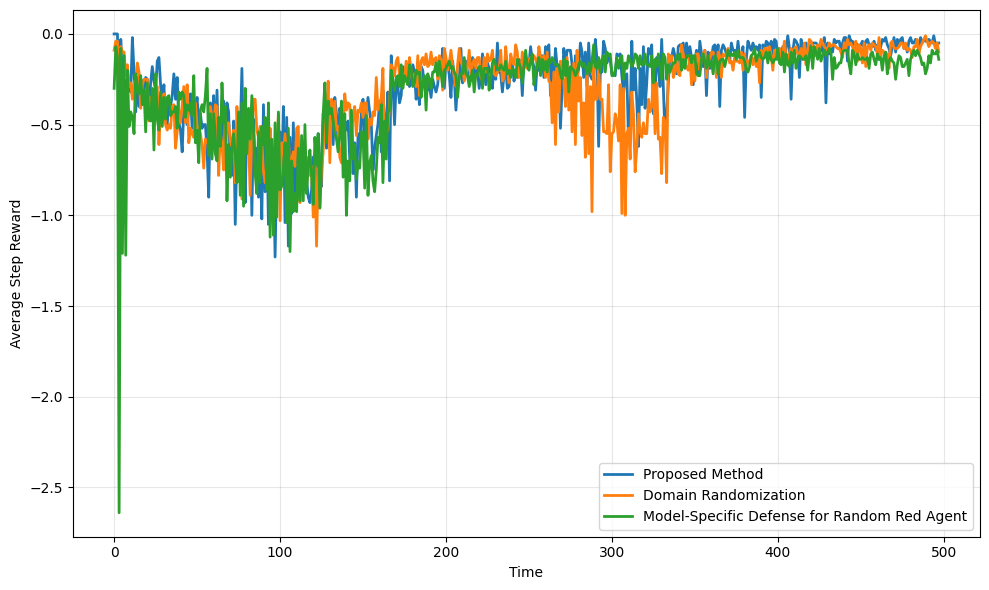

In [25]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def average_curves(curves):
    """Averages step reward curves across episodes."""
    return np.mean(curves, axis=0)


# Defense methods to compare
defense_methods = {
    "Proposed Method": "step_rewards_our.txt",
    "Domain Randomization": "step_rewards_DR.txt",
    "Model-Specific Defense for Random Red Agent": "step_rewards_Rand.txt",
    # "Model-Specific Defense for Impacter Red Agent": "step_rewards_Impacter.txt"
}

folder = "FSMultipleSwitchAgent1"  # Current folder (change if needed)

# Load and average each defense method
all_curves = []
labels = []

for label, filename in defense_methods.items():
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        print(f"WARNING: {filepath} not found, skipping.")
        continue
    
    curves = load_step_rewards(filepath)
    if len(curves) == 0:
        print(f"WARNING: No data in {filepath}")
        continue
    
    avg_curve = average_curves(curves)
    all_curves.append(avg_curve)
    labels.append(label)
    print(f"Loaded {label}: {len(curves)} episodes")

# Plot all methods together
plt.figure(figsize=(10, 6))
for curve, label in zip(all_curves, labels):
    plt.plot(curve, label=label, linewidth=2)

# plt.title("Average Step Reward Comparison: Defense Methods")
plt.xlabel("Time")
plt.ylabel("Average Step Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig("defense_comparison.png", dpi=180)

In [ ]:
import os
import re
import numpy as np


def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")
    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)
    if len(step_rewards) == 0:
        return np.empty((0, 0))
    return np.vstack(step_rewards)


def cumulative_mean_std(curves, transition_points):
    """Return mean/std of cumulative rewards at selected transition points."""
    if curves.size == 0:
        return np.array([]), np.array([])
    cumulative = np.cumsum(curves, axis=1)
    indices = [tp - 1 for tp in transition_points]
    values = cumulative[:, indices]
    means = np.mean(values, axis=0)
    stds = np.std(values, axis=0)
    return means, stds


def format_stat(mean, std):
    return f"{mean:.2f} ± {std:.2f}"

folder = "FSMultipleSwitchAgent1"
filenames = {
    "Proposed Defense": "step_rewards_our.txt",
    "GNN Domain Randomization": "step_rewards_DR.txt",
    "Model-Specific (ID 11)": "step_rewards_Rand.txt",
}

H = 500
transition_points = [H // 4, 2 * H // 4, 3 * H // 4, H]
phase_names = ["Finite-State", "Target A", "Impacter", "Sleep"]

summary = []
for label, filename in filenames.items():
    path = os.path.join(folder, filename)
    if not os.path.exists(path):
        print(f"WARNING: file not found: {path}")
        continue

    curves = load_step_rewards(path)
    if curves.size == 0:
        print(f"WARNING: no episodes loaded from {path}")
        continue

    means, stds = cumulative_mean_std(curves, transition_points)
    summary.append((label, means, stds, curves.shape[0]))
    print(f"Loaded {label}: {curves.shape[0]} episodes")


# Print summary table
header = ["Method"] + [f"{name} (t={tp})" for name, tp in zip(phase_names, transition_points)]
print("\n" + " | ".join(header))
print("-" * (len(header) * 20))
for label, means, stds, n in summary:
    row = [label] + [format_stat(m, s) for m, s in zip(means, stds)]
    print(" | ".join(row))

# LaTeX-friendly output
print("\nLaTeX table rows:")
for label, means, stds, n in summary:
    values = [f"${mean:.2f} \pm {std:.2f}$" for mean, std in zip(means, stds)]
    print(f"{label} & {' & '.join(values)} \\")


Loaded Proposed Method: 100 episodes
Loaded Domain Randomization: 100 episodes
Loaded Model-Specific Defense for Random Red Agent: 100 episodes
[-0.528      -0.33544    -0.18392    -0.07544715]
[-0.52592    -0.27352    -0.32424    -0.09138211]
[-0.57608    -0.3512     -0.1656     -0.13804878]


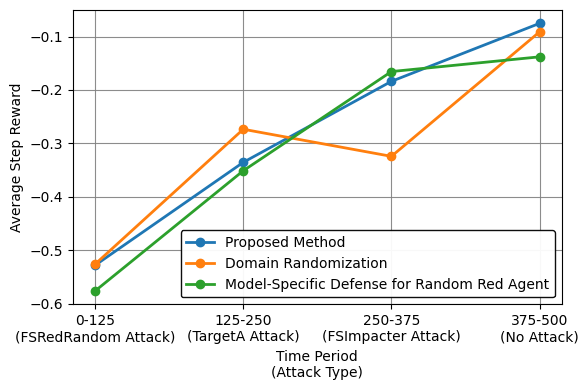

In [26]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")
    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)
    return np.array(step_rewards)

def average_by_agent_period(curves, total_steps=500, num_agents=4):
    """Averages rewards for each agent period (500/4 = 125 steps each)."""
    period_length = total_steps // num_agents
    period_averages = []
    
    for i in range(num_agents):
        start = i * period_length
        end = start + period_length
        period_rewards = curves[:, start:end]  # All episodes, this period
        avg_reward = np.mean(period_rewards)
        period_averages.append(avg_reward)
    
    return np.array(period_averages)

# Defense methods to compare
defense_methods = {
    "Proposed Method": "step_rewards_our.txt",
    "Domain Randomization": "step_rewards_DR.txt",
    "Model-Specific Defense for Random Red Agent": "step_rewards_Rand.txt",
    # "Model-Specific Defense for Impacter Red Agent": "step_rewards_Impacter.txt"
}

folder = "FSMultipleSwitchAgent1"

# Load and compute period averages
all_period_avgs = []
labels = []

for label, filename in defense_methods.items():
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        print(f"WARNING: {filepath} not found, skipping.")
        continue
    
    curves = load_step_rewards(filepath)
    if len(curves) == 0:
        print(f"WARNING: No data in {filepath}")
        continue
    
    period_avgs = average_by_agent_period(curves)
    all_period_avgs.append(period_avgs)
    labels.append(label)
    print(f"Loaded {label}: {len(curves)} episodes")

# Plot
x = np.arange(1, 5)  # Agent periods 1, 2, 3, 4
plt.figure(figsize=(6, 4))

for period_avgs, label in zip(all_period_avgs, labels):
    plt.plot(x, period_avgs, marker='o', label=label, linewidth=2)
    print(period_avgs)

plt.xlabel("Time Period\n(Attack Type)")
plt.ylabel("Average Step Reward")
plt.xticks(x, ["0-125\n(FSRedRandom Attack)", "125-250\n(TargetA Attack)", "250-375\n(FSImpacter Attack)", "375-500\n(No Attack)" ])
leg = plt.legend(edgecolor="black",framealpha=0.95)
leg.get_frame().set_linewidth(1)
        # leg.get_frame().set_edgecolor("black")
plt.grid(True, alpha=0.9, color='gray')
plt.tight_layout()
plt.savefig("res4.jpg", dpi=180)
plt.show()

Loaded Proposed Method: 100 episodes
Loaded Domain Randomization: 100 episodes
Loaded Model-Specific Defense for Random Red Agent: 100 episodes


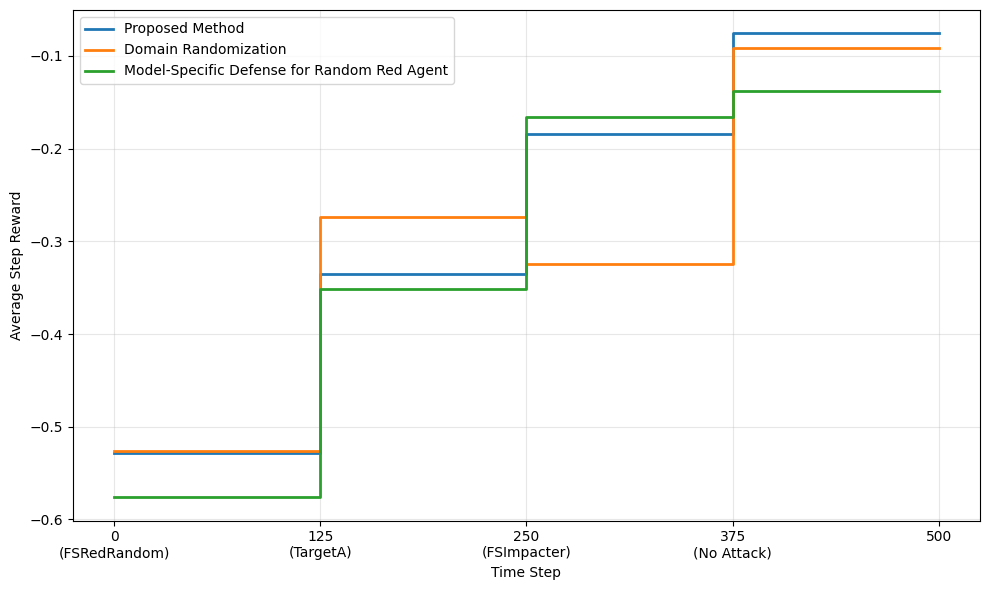

In [27]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")
    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)
    return np.array(step_rewards)

def average_by_agent_period(curves, total_steps=500, num_agents=4):
    """Averages rewards for each agent period (500/4 = 125 steps each)."""
    period_length = total_steps // num_agents
    period_averages = []
    
    for i in range(num_agents):
        start = i * period_length
        end = start + period_length
        period_rewards = curves[:, start:end]  # All episodes, this period
        avg_reward = np.mean(period_rewards)
        period_averages.append(avg_reward)
    
    return np.array(period_averages)

# Defense methods to compare
defense_methods = {
    "Proposed Method": "step_rewards_our.txt",
    "Domain Randomization": "step_rewards_DR.txt",
    "Model-Specific Defense for Random Red Agent": "step_rewards_Rand.txt",
    # "Model-Specific Defense for Impacter Red Agent": "step_rewards_Impacter.txt"
}

folder = "FSMultipleSwitchAgent1"

# Load and compute period averages
all_period_avgs = []
labels = []

for label, filename in defense_methods.items():
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        print(f"WARNING: {filepath} not found, skipping.")
        continue
    
    curves = load_step_rewards(filepath)
    if len(curves) == 0:
        print(f"WARNING: No data in {filepath}")
        continue
    
    period_avgs = average_by_agent_period(curves)
    all_period_avgs.append(period_avgs)
    labels.append(label)
    print(f"Loaded {label}: {len(curves)} episodes")

# Plot with step function
plt.figure(figsize=(10, 6))

for period_avgs, label in zip(all_period_avgs, labels):
    # Create step function: [0, 125, 125, 250, 250, 375, 375, 500]
    x_step = [0, 125, 125, 250, 250, 375, 375, 500]
    # Repeat each average: [avg1, avg1, avg2, avg2, avg3, avg3, avg4, avg4]
    y_step = [period_avgs[0], period_avgs[0], 
              period_avgs[1], period_avgs[1],
              period_avgs[2], period_avgs[2],
              period_avgs[3], period_avgs[3]]
    
    plt.plot(x_step, y_step, label=label, linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Average Step Reward")
plt.xticks([0, 125, 250, 375, 500], 
           ["0\n(FSRedRandom)", "125\n(TargetA)", "250\n(FSImpacter)", "375\n(No Attack)", "500"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig("defense_comparison_by_period.png", dpi=180)

NameError: name 'mean_belief' is not defined

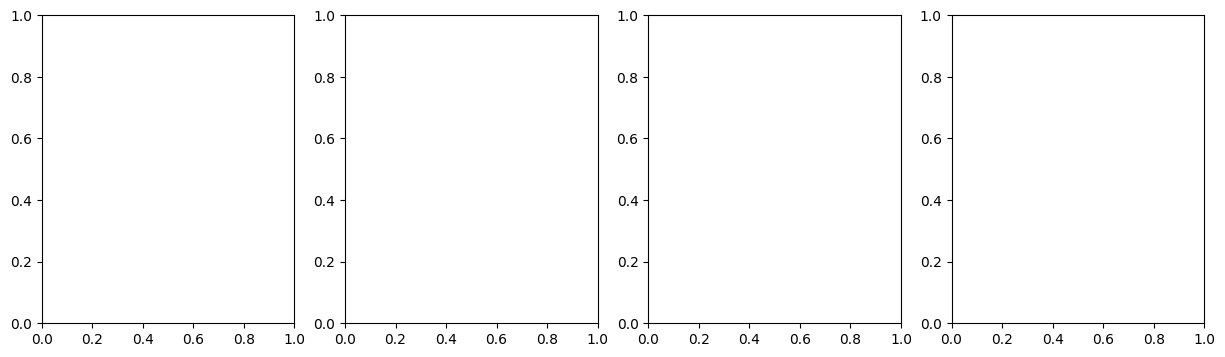

In [28]:

# Calculate belief jumps at transition points
transition_points = [100, 200, 300, 400]
window = 100  # Look 10 steps before/after transition
period_titles = [
    "Mid-Random Attack\n(50 steps before/after t=100)",
    "Target A→Impacter Transition\n(50 steps before/after t=200)",
    "Impacter→Sleep Transition\n(50 steps before/after t=300)",
    "Mid-No Attack\n(50 steps before/after t=400)"
]
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
i = 0
for idx, (trans_point, ax, title) in enumerate(zip(transition_points, axes, period_titles)):
    if i == 0:
        window_a = 50; window_b=50
    elif i == 1:
        window_a = 50; window_b=50
    elif i == 2:
        window_a = 50; window_b=50
    else:
        window_a = 50; window_b=50
        
    i += 1
    before = mean_belief[trans_point-window_b:trans_point, agent_ids]
    after = mean_belief[trans_point:trans_point+window_a, agent_ids]
    
    delta = after.mean(axis=0) - before.mean(axis=0)
    
    colors = ['green' if d > 0 else 'red' for d in delta]
    ax.bar(agent_labels, delta, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("Change in Posterior Probability")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim([-0.04,0.025])

plt.tight_layout()
plt.savefig("res5.jpg", dpi=180)
plt.show()




Loaded Proposed Method: 100 episodes
Loaded Domain Randomization: 100 episodes
Loaded Model-Specific Defense for Random Red Agent: 100 episodes
[ -66.         -107.93       -130.92       -140.76305221]
[ -65.74        -99.93       -140.46       -152.30923695]
[ -72.01       -115.91       -136.61       -154.20682731]


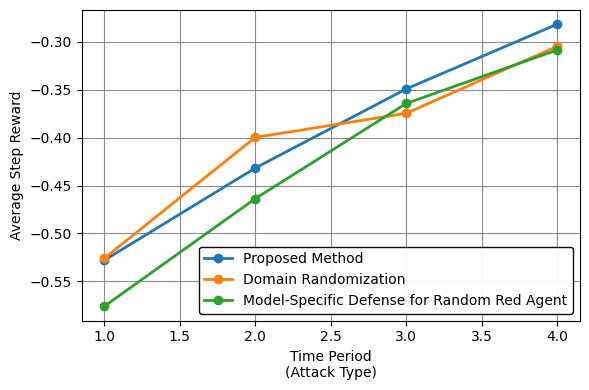

In [25]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

def load_step_rewards(path):
    """Loads all step reward sequences from a step_rewards file."""
    step_rewards = []
    pattern = re.compile(r"Episode \d+ step_rewards: \[(.*?)\]")
    with open(path, "r") as f:
        for line in f:
            m = pattern.search(line)
            if m:
                rewards = np.fromstring(m.group(1), sep=",")
                step_rewards.append(rewards)
    return np.array(step_rewards)

def average_by_agent_period(curves, total_steps=500, num_agents=4):
    """Averages rewards for each agent period (500/4 = 125 steps each)."""
    period_length = total_steps // num_agents
    period_averages = []
    
    for i in range(num_agents):
        start = i * period_length
        end = start + period_length
        period_rewards = curves[:, :end]   # All episodes, this period
        avg_reward = np.mean(period_rewards)
        period_averages.append(avg_reward)
    
    return np.array(period_averages)

# Defense methods to compare
defense_methods = {
    "Proposed Method": "step_rewards_our.txt",
    "Domain Randomization": "step_rewards_DR.txt",
    "Model-Specific Defense for Random Red Agent": "step_rewards_Rand.txt",
    # "Model-Specific Defense for Impacter Red Agent": "step_rewards_Impacter.txt"
}

folder = "FSMultipleSwitchAgent1"

# Load and compute period averages
all_period_avgs = []
labels = []

for label, filename in defense_methods.items():
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        print(f"WARNING: {filepath} not found, skipping.")
        continue
    
    curves = load_step_rewards(filepath)
    if len(curves) == 0:
        print(f"WARNING: No data in {filepath}")
        continue
    
    period_avgs = average_by_agent_period(curves)
    all_period_avgs.append(period_avgs)
    labels.append(label)
    print(f"Loaded {label}: {len(curves)} episodes")

# Plot
x = np.arange(1, 5)  # Agent periods 1, 2, 3, 4
plt.figure(figsize=(6, 4))

for period_avgs, label in zip(all_period_avgs, labels):
    plt.plot(x, period_avgs, marker='o', label=label, linewidth=2)
    print(period_avgs*[125, 250, 375, 500])
    

plt.xlabel("Time Period\n(Attack Type)")
plt.ylabel("Average Step Reward")
# plt.xticks(x, ["0-125\n(FSRedRandom Attack)", "125-250\n(TargetA Attack)", "250-375\n(FSImpacter Attack)", "375-500\n(No Attack)" ])
leg = plt.legend(edgecolor="black",framealpha=0.95)
leg.get_frame().set_linewidth(1)
        # leg.get_frame().set_edgecolor("black")
plt.grid(True, alpha=0.9, color='gray')
plt.tight_layout()
plt.savefig("res4.jpg", dpi=180)
plt.show()

# Table 3 in Revised Paper (May 3, 2026)

In [13]:


def average_by_agent_period(curves, total_steps=500, num_agents=4):
    period_length = total_steps // num_agents
    means = []
    stds = []

    for i in range(num_agents):
        end = (i + 1) * period_length
        
        # cumulative return per episode
        returns = np.sum(curves[:, :end], axis=1)
        
        means.append(np.mean(returns))
        stds.append(np.std(returns))

        print(f"Up to {end}: Mean={means[-1]:.2f}, Std={stds[-1]:.2f}")

    return np.array(means), np.array(stds)


# Defense methods to compare
defense_methods = {
    "Proposed Method": "step_rewards_our.txt",
    "Domain Randomization": "step_rewards_DR.txt",
    "Model-Specific Defense for Random Red Agent": "step_rewards_Rand.txt",
    # "Model-Specific Defense for Impacter Red Agent": "step_rewards_Impacter.txt"
}

folder = "FSMultipleSwitchAgent1"

# Load and compute period averages
all_period_avgs = []
all_period_stds = []

labels = []

for label, filename in defense_methods.items():
    filepath = os.path.join(folder, filename)
    if not os.path.exists(filepath):
        print(f"WARNING: {filepath} not found, skipping.")
        continue
    
    curves = load_step_rewards(filepath)
    if len(curves) == 0:
        print(f"WARNING: No data in {filepath}")
        continue
    
    period_avgs, period_stds = average_by_agent_period(curves)
    all_period_avgs.append(period_avgs)
    all_period_stds.append(period_stds)
    labels.append(label)
    print(f"Loaded {label}: {len(curves)} episodes")




Up to 125: Mean=-66.00, Std=24.90
Up to 250: Mean=-107.93, Std=28.98
Up to 375: Mean=-130.92, Std=36.05
Up to 500: Mean=-140.20, Std=36.09
Loaded Proposed Method: 100 episodes
Up to 125: Mean=-65.74, Std=18.99
Up to 250: Mean=-99.93, Std=25.86
Up to 375: Mean=-140.46, Std=45.16
Up to 500: Mean=-151.70, Std=44.99
Loaded Domain Randomization: 100 episodes
Up to 125: Mean=-72.01, Std=19.16
Up to 250: Mean=-115.91, Std=28.94
Up to 375: Mean=-136.61, Std=30.55
Up to 500: Mean=-153.59, Std=31.89
Loaded Model-Specific Defense for Random Red Agent: 100 episodes
